# 01 Subspace Representability

Solves all the statevector matrices and looks into the spectral accuracy and representability of the QSE subspace

In [1]:
%load_ext autoreload
%autoreload 2

import itertools
import sys
from functools import partial
from types import SimpleNamespace

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.linalg import orth

from qibochem.ansatz.ucc import (Ansatz_UCCGSD, Ansatz_UCCSD, Ansatz_UCCSDSinglet,
                                    Ansatz_kUpCCGSDSinglet)
from qibochem.measurement.protocol import StateVectorProtocol

from config import DATA_DIR, PROJECT_ROOT, PROCESSED_DATAFRAMES_DIR
from notebook_utils.mat_fn import solve_energy_spin_th
from notebook_utils.general import (parse_active_space, read_npz,
                                    save_figure)
from notebook_utils.analysis import get_max_states
from notebook_utils.chem import get_vqe_spin_contamination
from notebook_utils.graphs import (show_scrollable_figs, plot_bad_spin_roots, plot_severe_spin_root_diagnostic,
                                    plot_projection_error_scatter, plot_tiered_error_ridgelines,
                                    plot_q1_best_root_transition_map, plot_s1_active_space_error)

sys.path.append(str(PROJECT_ROOT / "scripts"))
from script_utils import MOLECULE_NAMES, load_qibo_mol, get_vqe_circuit

SV_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_data.pkl"
QSE_STATE_MATRICES_DIR = DATA_DIR / "raw_matrices" / "qse_state_matrices"

df_sv = pd.read_pickle(SV_DATAFRAME_PATH)

## Load in Data and Solve Hc=ESc

In [2]:
# Define QSE State matrices, used to project wavefunctions in basis of expansion coefficients
# onto second quantised determinant basis 
def load_qse_state_matrices(path):
    qse_state_matrices = {}
    
    for file in sorted(path.rglob("*.npz")):
        row = read_npz(file)
        key = (row["molecule"], row["active_space"], row["ansatz"], row["expansion"])
        qse_state_matrices[key] = np.asarray(row["qse_state_matrix"], dtype=float)

    return qse_state_matrices

qse_state_matrices = load_qse_state_matrices(QSE_STATE_MATRICES_DIR)

In [3]:
# Get the projection value for each of the exact pyscf roots onto the QSE subspace
def project_exact_roots(qse_subspace, pyscf_casci_pvec):
    qse_subspace = np.asarray(qse_subspace, dtype=complex)
    exact_root_projections = {}

    for root_label, exact_pvec in pyscf_casci_pvec.items():
        exact_pvec = np.asarray(exact_pvec, dtype=complex)
        exact_norm = np.linalg.norm(exact_pvec)

        if exact_norm == 0:
            exact_root_projections[root_label] = 0.0
            continue

        exact_pvec = exact_pvec / exact_norm
        projection_coeffs = qse_subspace.conj().T @ exact_pvec
        projection_weight = np.sum(np.abs(projection_coeffs) ** 2)

        exact_root_projections[root_label] = float(np.real_if_close(projection_weight))

    return exact_root_projections


In [4]:
# Group triplet energies and exact-state projections
# Record the maximum sector splitting for both quantities
TRIPLET_SECTORS = ("0", "p1", "m1")

def group_triplet_energies(values):
    """
    Group triplet energies that are in a list [E00, E0p1, E0m1, E10, E1p1, E1m1 ...]
    The list of energies might not be a multiple of 3, so group every 3 first, then 
    the remaining are grouped together 
    """
    values = np.asarray(values, dtype=float)
    grouped_energies = []
    energy_splittings = []

    for i in range(0, len(values), 3):
        group = values[i:i+3]

        grouped_energies.append(float(np.mean(group)))

        if len(group) != 1: 
            energy_splittings.append(float(np.ptp(group)))
        else:
            energy_splittings.append(np.nan)

    return grouped_energies, energy_splittings


def group_triplet_projections(projection):
    """
    Group triplet projection values from a dictionary of the form 
    {"0_0": ..., "0_p1": ..., "0_m1": ..., ...}
    """
    num_roots = len(projection) // 3
    # Re shape dict into array
    sector_projections = np.asarray([
        [projection[f"{root}_{sector}"] for sector in TRIPLET_SECTORS]
        for root in range(num_roots)
    ], dtype=float)

    grouped_projections = {
        str(root): float(mean_projection)
        for root, mean_projection in enumerate(sector_projections.mean(axis=1))
    }
    projection_splittings = {
        f"t{root + 1}": float(splitting)
        for root, splitting in enumerate(np.ptp(sector_projections, axis=1))
    }

    return grouped_projections, projection_splittings


In [5]:
# Define spin contamination and root-level metric columns
def get_spin_contamination(spin_values, expansion):
    spin_values = np.asarray(spin_values, dtype=float)

    if expansion == "singlet":
        return np.abs(spin_values).tolist()


    spin_contamination = []
    for i in range(0, len(spin_values), 3):
        group = spin_values[i:i+3]
        spin_contamination.append(float(np.max(np.abs(group-2.0))))

    return spin_contamination


state_labels = [f"s{i}" for i in range(11)] + [f"t{i}" for i in range(1, 11)]
metrics = ("error", "projection", "spin_contamination")
metric_columns = [f"{state}_{metric}" for state in state_labels for metric in metrics]


In [6]:
# Solve every QSE row and add its energies, spin data, subspace and root metrics
def solve_subspace_row(row):
    qse_energies, _, spin_values = solve_energy_spin_th(
        row["H"], row["S"], row["S2"], threshold=1e-8
    )
    full_spin_values = np.asarray(spin_values, dtype=float).tolist()
    full_spin_contamination = get_spin_contamination(spin_values, row["expansion"])

    # Get the QSE state matrix for subspace calculation
    key = (row["molecule"], row["active_space"], row["ansatz"], row["expansion"])
    qse_state_matrix = qse_state_matrices[key]
    qse_basis_subspace = orth(qse_state_matrix)

    # Calculate the projection of the exact roots
    exact_qse_projection = project_exact_roots(qse_basis_subspace, row["pyscf_casci_pvec"])
    energy_splittings = []
    projection_splittings = {}

    # Group the three triplet spin sectors into physical roots
    if row["expansion"] == "triplet":
        qse_energies, energy_splittings = group_triplet_energies(qse_energies)
        exact_qse_projection, projection_splittings = group_triplet_projections(
            exact_qse_projection
        )
    # Split the roots into separate columns
    root_metrics = {column: np.nan for column in metric_columns}
    if row["expansion"] == "singlet":
        # For singlets start with s0 to s10
        prefix, start = "s", 0
        exact_energies = row["pyscf_casci_energies"][:11]
        matched_qse_energies = qse_energies[:11]
    else:
        # Triplets start with t1 to t10
        prefix, start = "t", 1
        exact_energies = row["pyscf_casci_energies"][:10]
        matched_qse_energies = qse_energies[:10]

    for root_index, exact_energy in enumerate(exact_energies):
        root = f"{prefix}{root_index + start}"
        has_qse_root = root_index < len(matched_qse_energies)
        qse_energy = matched_qse_energies[root_index] if has_qse_root else None

        # Record all the energy errors in mHa
        root_metrics[f"{root}_error"] = (
            np.nan if qse_energy is None else 1000 * abs(qse_energy - exact_energy)
        )
        # Record projection and spin contamination 
        root_metrics[f"{root}_projection"] = exact_qse_projection[str(root_index)]
        root_metrics[f"{root}_spin_contamination"] = (
            np.nan if qse_energy is None else full_spin_contamination[root_index]
        )

    return pd.Series({
        "qse_energies": qse_energies,
        "full_spin_values": full_spin_values,
        "full_spin_contamination": full_spin_contamination,
        "exact_qse_projection": exact_qse_projection,
        "energy_splittings": energy_splittings,
        "projection_splittings": projection_splittings,
        **root_metrics,
    })


result_columns = [
    "qse_energies",
    "full_spin_values",
    "full_spin_contamination",
    "exact_qse_projection",
    "energy_splittings",
    "projection_splittings",
    *metric_columns,
]

df_sv[result_columns] = df_sv.apply(solve_subspace_row, axis=1)


In [7]:
# Show the mean and median splitting for triplets Energy and Projection Value 
# Generally very low across all triplet states, not significant
TRIPLET_ROOTS = [f"t{root}" for root in range(1, 11)]
triplet_rows = df_sv["expansion"] == "triplet"

triplet_energy_values = 1000 * pd.DataFrame(
    df_sv.loc[triplet_rows, "energy_splittings"].tolist(),
    index=df_sv.index[triplet_rows],
).rename(columns=lambda root: f"t{root + 1}").reindex(columns=TRIPLET_ROOTS)

triplet_projection_values = pd.DataFrame(
    df_sv.loc[triplet_rows, "projection_splittings"].tolist(),
    index=df_sv.index[triplet_rows],
).reindex(columns=TRIPLET_ROOTS)

df_triplet_splitting_summary = pd.DataFrame({
    "mean_energy_splitting_mHa": triplet_energy_values.mean(),
    "median_energy_splitting_mHa": triplet_energy_values.median(),
    "mean_projection_splitting": triplet_projection_values.mean(),
    "median_projection_splitting": triplet_projection_values.median(),
})

df_sv.drop(columns=["energy_splittings", "projection_splittings"], inplace=True)

df_triplet_splitting_summary

,mean_energy_splitting_mHa,median_energy_splitting_mHa,mean_projection_splitting,median_projection_splitting
t1,0.027034,3.467449e-09,0.000106,1.332268e-15
t2,0.021026,6.110668e-09,0.000155,2.109424e-15
t3,0.193333,1.884359e-08,0.000817,2.553513e-15
t4,2.004334,2.781860e-06,0.000551,1.740962e-09
t5,8.566130,9.123255e-06,0.001172,1.382347e-08
t6,4.778075,2.710229e-05,0.003009,2.589958e-08
t7,9.721556,4.962942e-05,0.008945,4.485428e-08
t8,5.531485,9.582334e-05,0.005202,9.481475e-08
t9,5.331644,3.404796e-04,0.005899,2.209964e-07
t10,5.751566,1.547330e-04,0.005758,7.189298e-08


In [8]:
df_sv

,molecule,active_space,ansatz,expansion,H,S,qse_dim,S2,pyscf_casci_energies,pyscf_casci_pvec,...,t7_spin_contamination,t8_error,t8_projection,t8_spin_contamination,t9_error,t9_projection,t9_spin_contamination,t10_error,t10_projection,t10_spin_contamination
0,Acetamide,2e2o,1UpCCGSDSinglet,singlet,"[[(-802.5633883162756+0j), (-4.698289217688655...","[[(3.9096898019756012+0j), (0.0228835930543396...",4,"[[(1.2656542480726785e-14+0j), 0j, (-6.5052130...","[-205.2944990546729, -204.82581813267245, -204...","{'0': [-0.15005468780119358, 0.0, -0.006284675...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Acetamide,2e2o,1UpCCGSDSinglet,triplet,"[[(-0.00804123337029232+0j), 0j, 0j, (0.192703...","[[(3.9211269059064024e-05+0j), 0j, 0j, (-0.000...",12,"[[(7.842253811508881e-05+0j), 0j, 0j, (-0.0018...",[-205.07455033363988],"{'0_0': [1.2772011986346633e-16, 0.0, -0.70710...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Acetamide,2e2o,2UpCCGSDSinglet,singlet,"[[(-802.5652804165668+0j), (-4.71721906907201+...","[[(3.9096990207381515+0j), (0.0229757934971892...",4,"[[(2.4868995751603507e-14+0j), (1.301042606982...","[-205.2944990546729, -204.82581813267245, -204...","{'0': [-0.15005468780119358, 0.0, -0.006284675...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Acetamide,2e2o,2UpCCGSDSinglet,triplet,"[[(-0.008106060468175108+0j), 0j, 0j, (0.19346...","[[(3.9527383846466035e-05+0j), 0j, 0j, (-0.000...",12,"[[(7.905476768700626e-05+0j), 0j, 0j, (-0.0018...",[-205.07455033363988],"{'0_0': [1.2772011986346633e-16, 0.0, -0.70710...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Acetamide,2e2o,3UpCCGSDSinglet,singlet,"[[(-802.5670885068249+0j), (-4.718526920088642...","[[(3.909707828949163+0j), (0.02298216377385717...",4,"[[(3.8219427622721014e-14+0j), 0j, (8.67361737...","[-205.2944990546729, -204.82581813267245, -204...","{'0': [-0.15005468780119358, 0.0, -0.006284675...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,Uracil,6e7o,UCCSD,triplet,"[[(-0.11042245041486087+0j), 0j, 0j, (-6.37046...","[[(0.0002718226282586167+0j), 0j, 0j, (1.56773...",147,"[[(0.0005436414375037656+0j), 0j, 0j, (3.13543...","[-406.95689685600695, -406.90419213472666, -40...","{'0_0': [-3.919148314149759e-08, 0.0, -3.51006...",...,0.000249,49.588408,0.749227,0.008626,41.675581,0.852014,0.000009,75.512346,0.023123,3.521307e-07
2516,Uracil,8e7o,UCCSD,singlet,"[[(-1627.9179451613252+0j), (0.151178922494367...","[[(3.998609492626249+0j), (-0.0003714519947059...",49,"[[(7.043982743019104e-07+0j), (3.4870941333265...","[-407.1214804205012, -406.94605481069067, -406...","{'0': [-2.3296044344376372e-06, 0.0, -8.024116...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2517,Uracil,8e7o,UCCSD,triplet,"[[(-0.05217935944762317+0j), 0j, 0j, (-0.01252...","[[(0.00012840277216497054+0j), 0j, 0j, (3.0821...",147,"[[(0.0002567898781715119+0j), 0j, 0j, (6.16475...","[-406.96118398246017, -406.95666451956214, -40...","{'0_0': [-1.949602093463748e-15, 0.0, -4.70314...",...,0.000036,103.054844,0.992659,0.000083,75.963489,0.520053,0.001542,86.294883,0.066816,1.538327e-04
2518,Uracil,8e8o,UCCSD,singlet,"[[(-1627.5906696076613+0j), (0.352919530145391...","[[(3.997797662312483+0j), (-0.0008670055522641...",64,"[[(1.4686254965902396e-06+0j), (-4.62676091070...","[-407.12243001960377, -406.9465993150982, -406...","{'0': [-1.2617166801127624e-06, 0.0, -1.826998...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# UCCSD Active Space Representability 

In [21]:
df_UCCSD = df_sv[df_sv["ansatz"] == "UCCSD"].copy()

# Extract minimal low-state error and exact-state projection data for viewing and plotting.
df_singlet_metrics = df_UCCSD.loc[
    df_UCCSD["expansion"] == "singlet",
    ["molecule", "active_space", "s0_error", "s1_error", "s0_projection", "s1_projection"],
].rename(columns={"s0_error": "s0", "s1_error": "s1"})

df_triplet_metrics = df_UCCSD.loc[
    df_UCCSD["expansion"] == "triplet",
    ["molecule", "active_space", "t1_error", "t2_error", "t1_projection", "t2_projection"],
].rename(columns={"t1_error": "t1", "t2_error": "t2"})

df_raw_data = df_singlet_metrics.merge(
    df_triplet_metrics, on=["molecule", "active_space"], validate="one_to_one"
)["molecule active_space s0 s1 t1 t2 s0_projection s1_projection t1_projection t2_projection".split()]

RAW_DATA_PATH = PROCESSED_DATAFRAMES_DIR / "uccsd_low_lying_state_errors.csv"
df_raw_data.to_csv(RAW_DATA_PATH, index=False)

display(df_raw_data)

,molecule,active_space,s0,s1,t1,t2,s0_projection,s1_projection,t1_projection,t2_projection
0,Acetamide,2e2o,3.126388e-10,1.136868e-10,2.557954e-10,NaN,1.000000,1.000000,1.000000,NaN
1,Acetamide,2e3o,2.842171e-11,5.684342e-10,1.989520e-10,3.694822e-10,1.000000,1.000000,1.000000,1.000000
2,Acetamide,4e3o,1.989520e-10,3.694822e-10,3.126388e-10,8.526513e-11,1.000000,1.000000,1.000000,1.000000
3,Acetamide,4e4o,1.684234e-03,4.736762e-07,1.052967e-06,1.375611e-08,0.999999,1.000000,1.000000,1.000000
4,Acetamide,4e5o,1.681263e-02,1.159011e-01,1.502646e-01,5.268806e-01,0.999991,0.999914,0.999838,0.999249
...,...,...,...,...,...,...,...,...,...,...
275,Uracil,6e5o,8.163510e-04,1.290474e+01,8.962048e-03,8.484685e+00,0.999999,0.963636,0.999989,0.970140
276,Uracil,6e6o,6.817154e-02,2.360855e+01,1.111510e+00,1.391322e+01,0.999950,0.934657,0.997365,0.954004
277,Uracil,6e7o,1.112834e-01,1.256096e+01,1.411799e+00,1.160086e+01,0.999918,0.974786,0.996804,0.975693
278,Uracil,8e7o,6.567789e-02,1.698436e+01,5.772826e+00,6.965219e+00,0.999953,0.946196,0.964993,0.997071



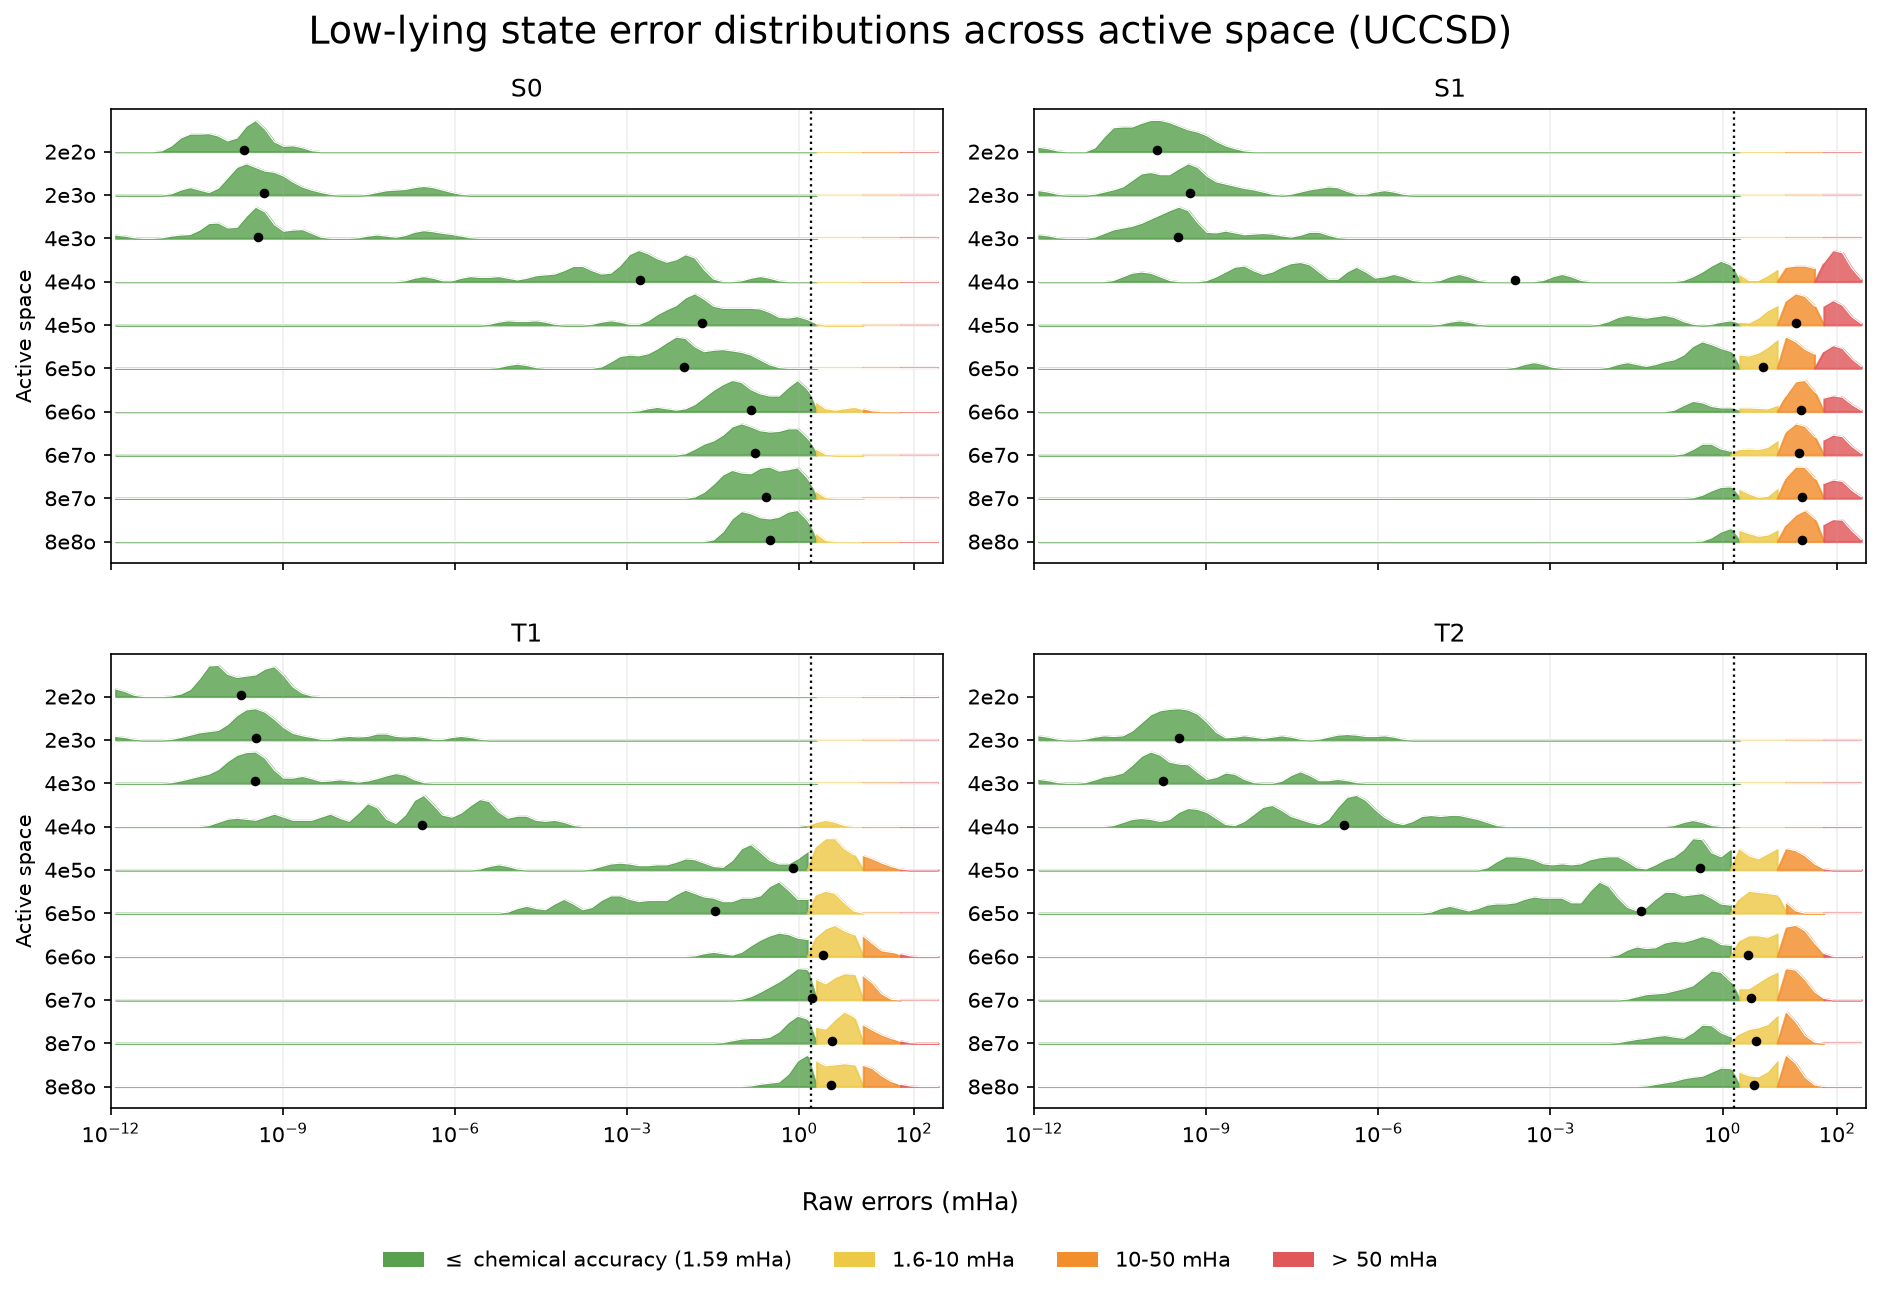

In [10]:
def get_low_state_error_data(df_raw_data):
    states = ["s0", "s1", "t1", "t2"]
    active_spaces = sorted(df_raw_data["active_space"].unique(), key=parse_active_space)

    return {
        active_space: {
            state: df_raw_data.loc[
                df_raw_data["active_space"] == active_space, state
            ].dropna().to_numpy()
            for state in states
        }
        for active_space in active_spaces
    }

uccsd_low_state_error_data = get_low_state_error_data(df_raw_data)

tiered_error_ridgeline_figure = plot_tiered_error_ridgelines(uccsd_low_state_error_data)
save_figure(
    tiered_error_ridgeline_figure,
    "active_space_representability",
    "uccsd_tiered_error_ridgelines",
)
show_scrollable_figs([tiered_error_ridgeline_figure])

{'s0': 280, 's1': 280, 't1': 280, 't2': 252}



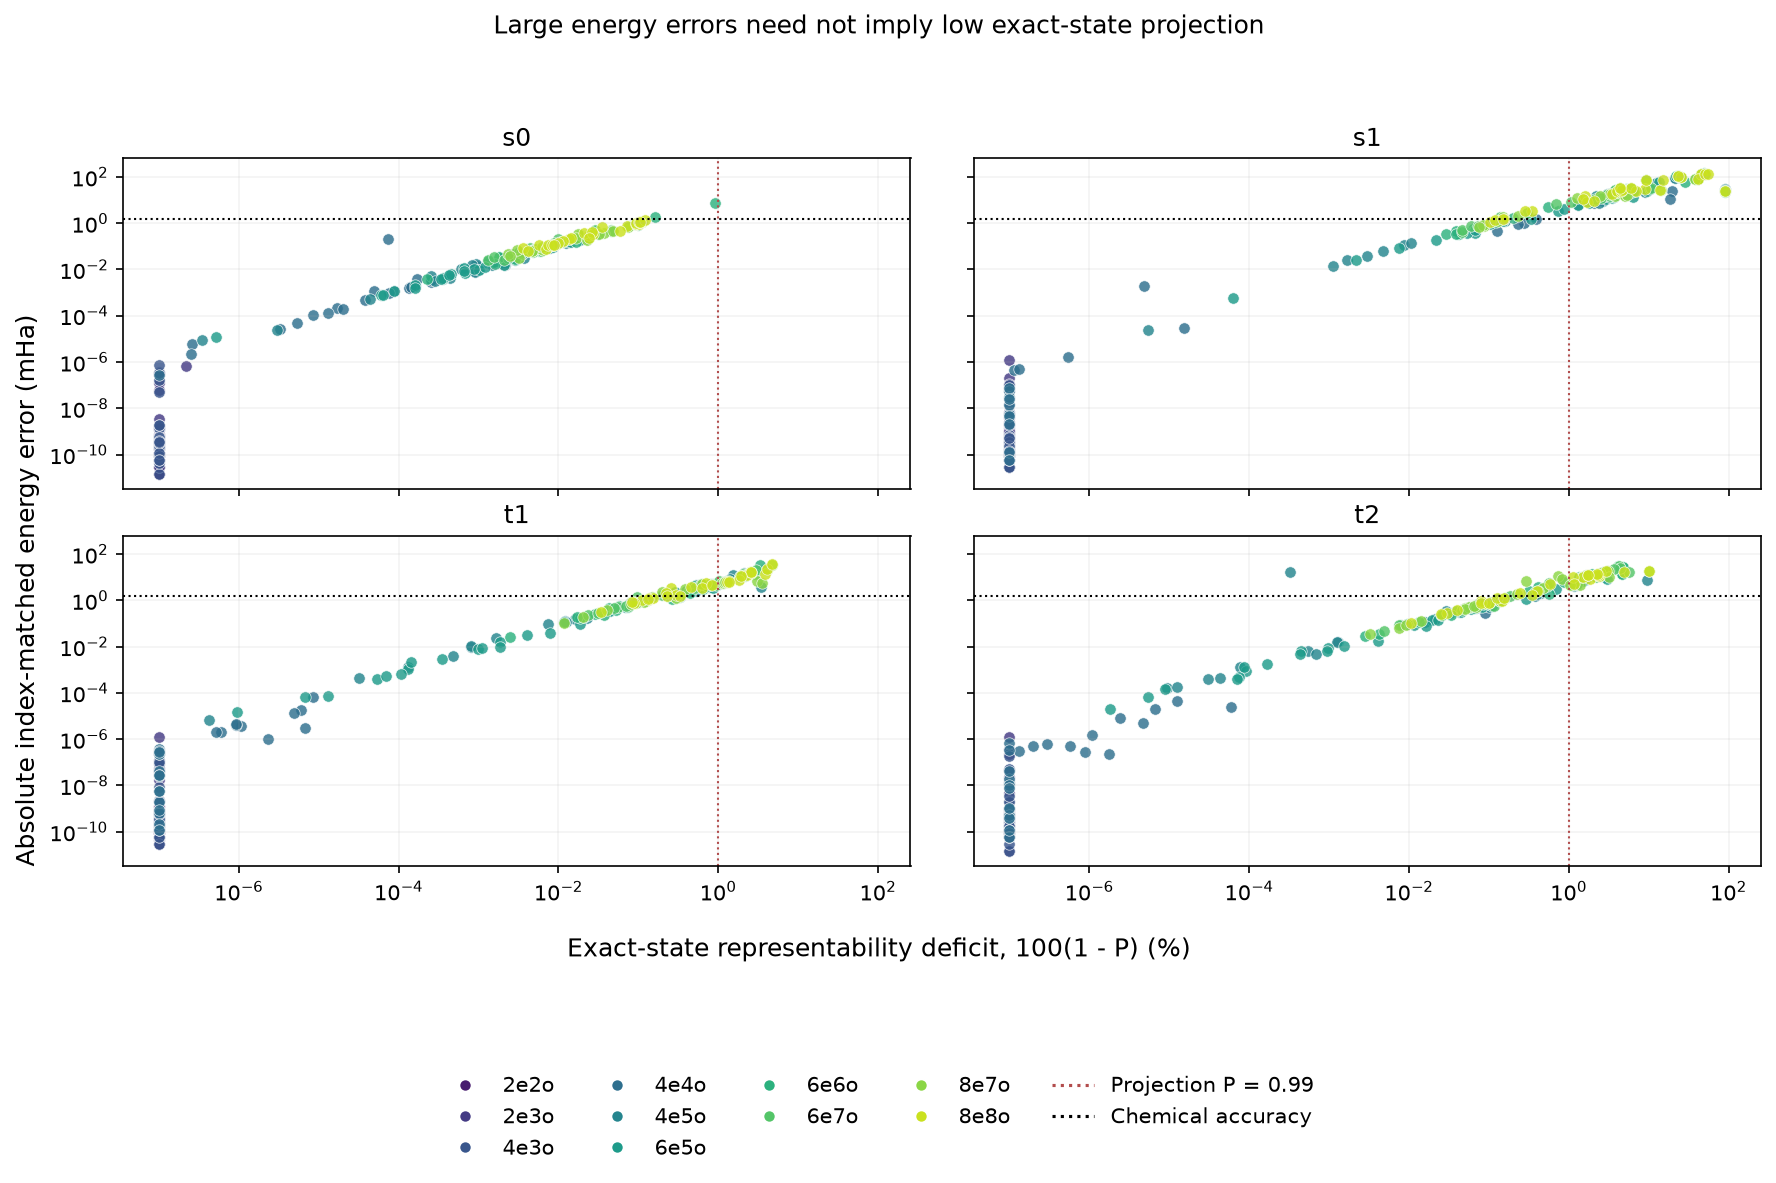

In [11]:
# Show the Projection vs Errors 
# Quantify real representability issues 
def get_projection_error_data(df_UCCSD):
    state_expansions = {"s0": "singlet", "s1": "singlet", "t1": "triplet", "t2": "triplet"}
    active_spaces = sorted(df_UCCSD["active_space"].unique(), key=parse_active_space)
    frames = [
        df_UCCSD.loc[
            df_UCCSD["expansion"] == expansion,
            ["molecule", "active_space", f"{state}_projection", f"{state}_error"],
        ].rename(columns={f"{state}_projection": "projection", f"{state}_error": "error_mHa"}).assign(state=state)
        for state, expansion in state_expansions.items()
    ]
    projection_error_data = pd.concat(frames, ignore_index=True).dropna(
        subset=["projection", "error_mHa"]
    )
    projection_error_data["deficit_percent"] = 100 * (1 - projection_error_data["projection"])
    projection_error_data["active_space"] = pd.Categorical(
        projection_error_data["active_space"], active_spaces, ordered=True
    )
    return projection_error_data.sort_values(["active_space", "state", "molecule"]).reset_index(drop=True)


df_projection_error_data = get_projection_error_data(df_UCCSD)
print(df_projection_error_data.groupby("state", observed=True).size().to_dict())

projection_error_figure = plot_projection_error_scatter(df_projection_error_data)
save_figure(
    projection_error_figure,
    "active_space_representability",
    "uccsd_error_vs_projection_deficit",
)
show_scrollable_figs([projection_error_figure])

## Molecule Specific Errors

Prepared 196 UCCSD S1 error records.



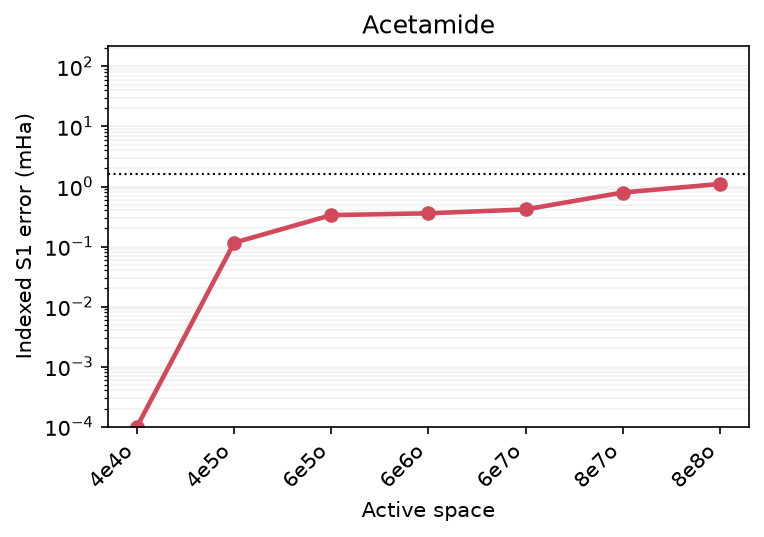
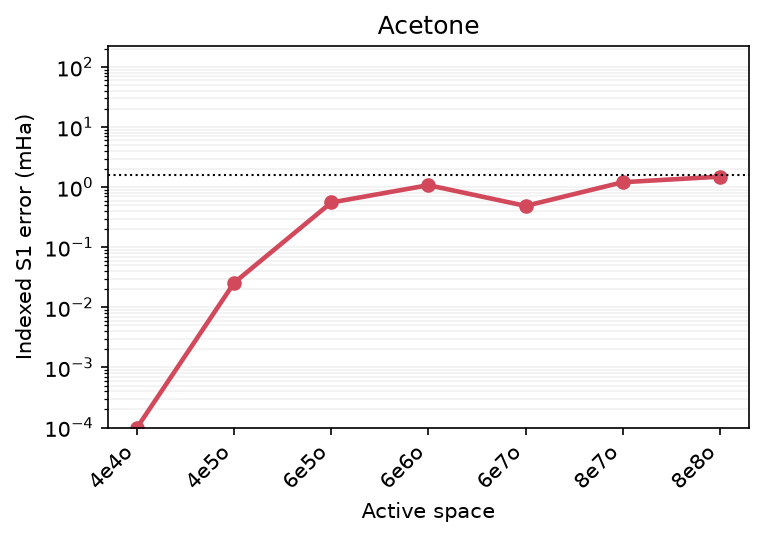
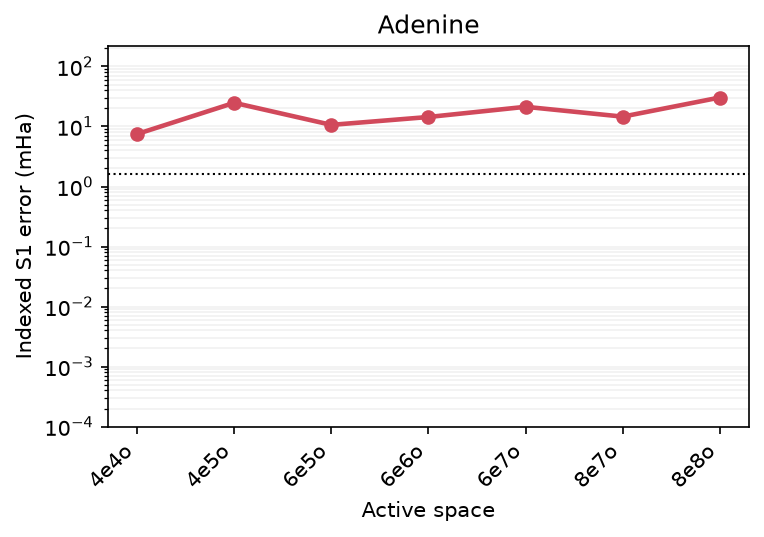
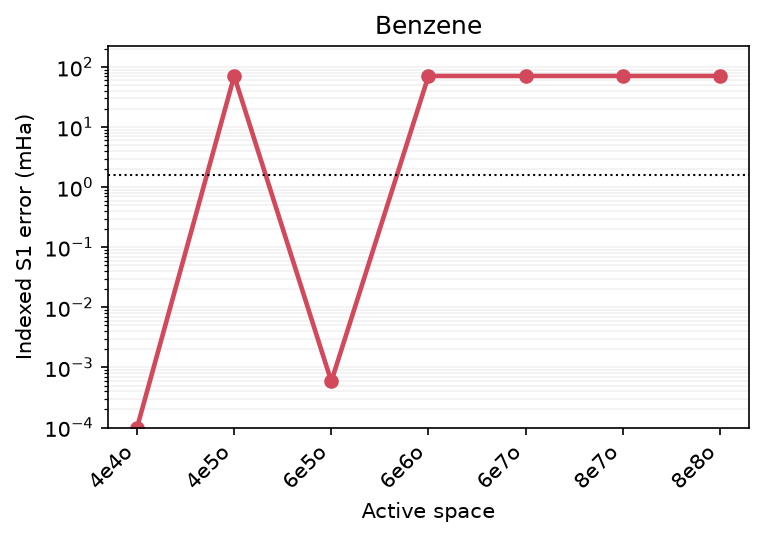
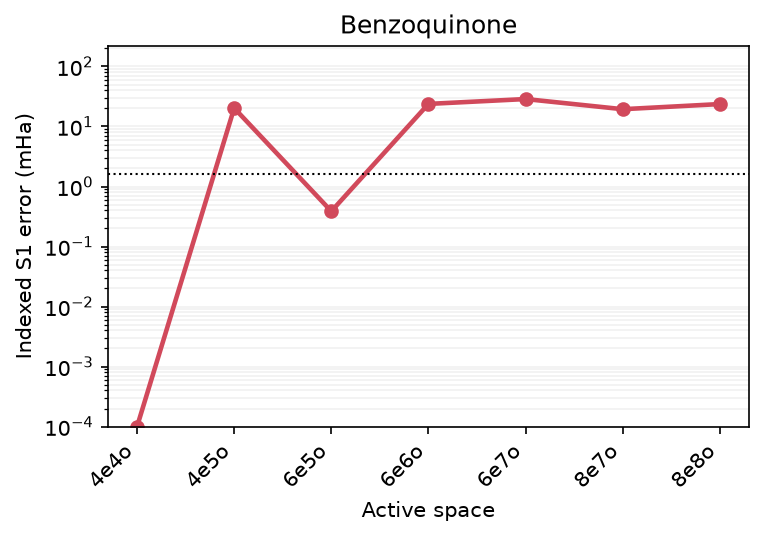
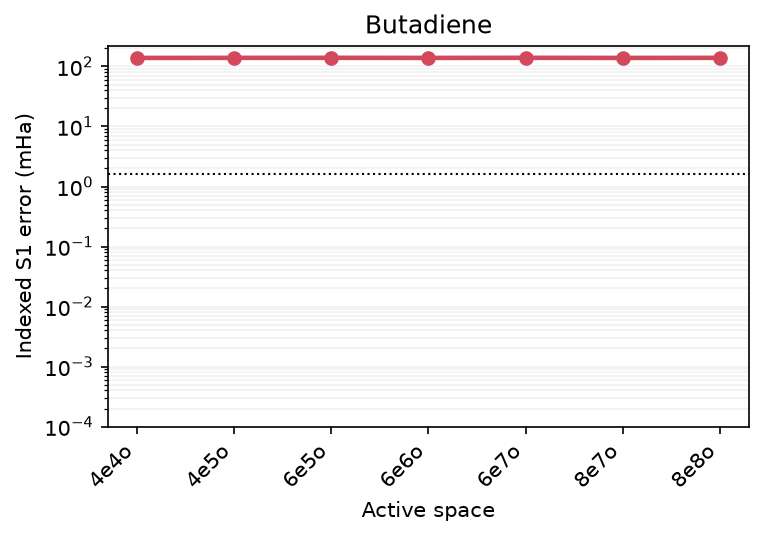
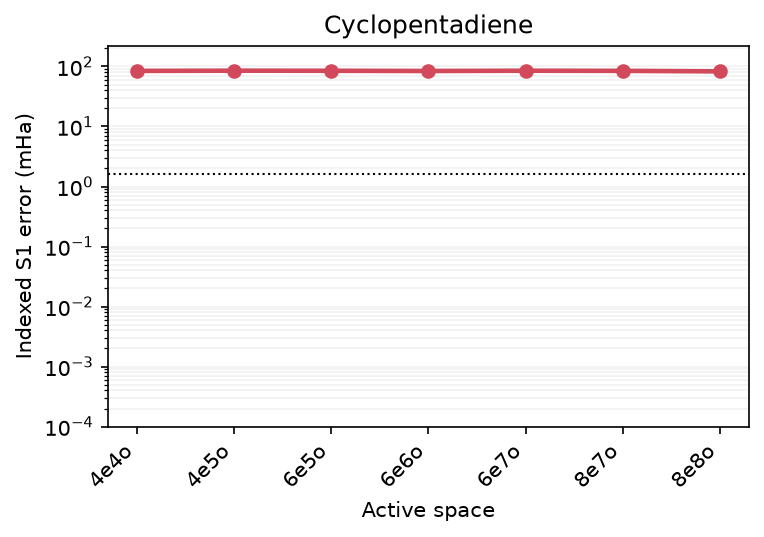
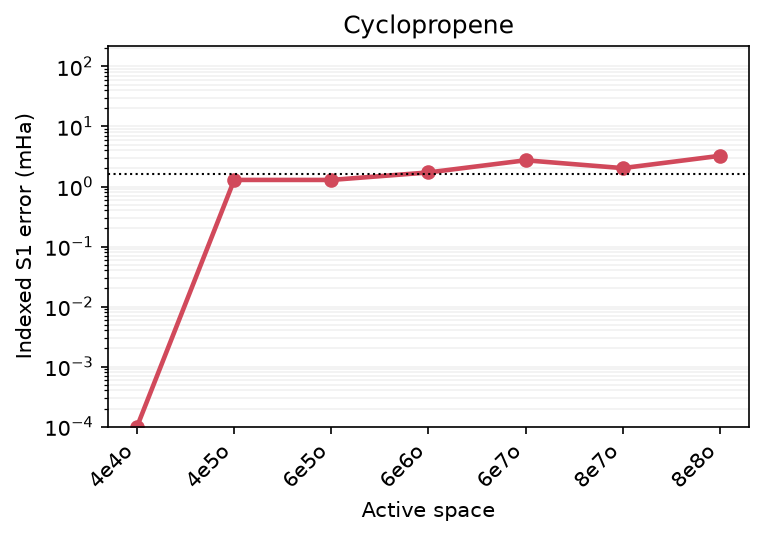
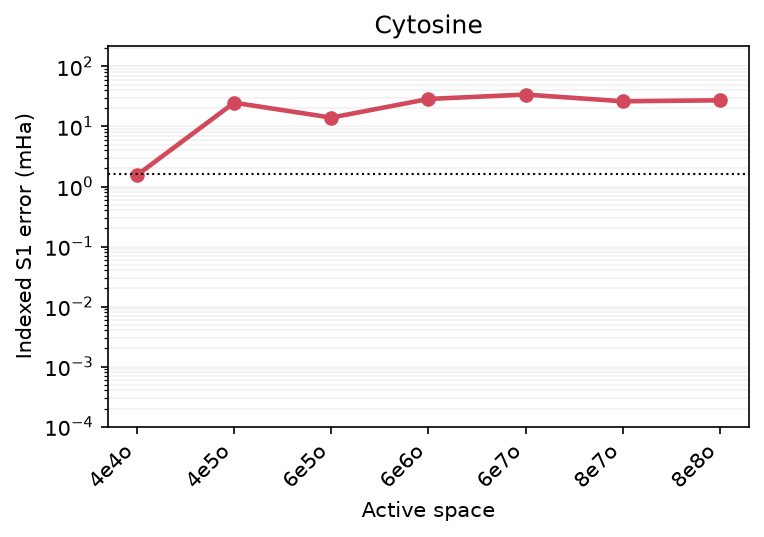
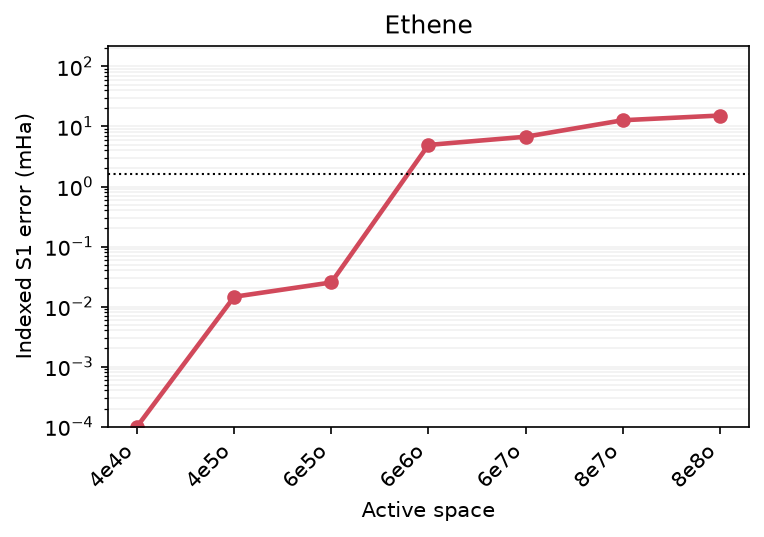
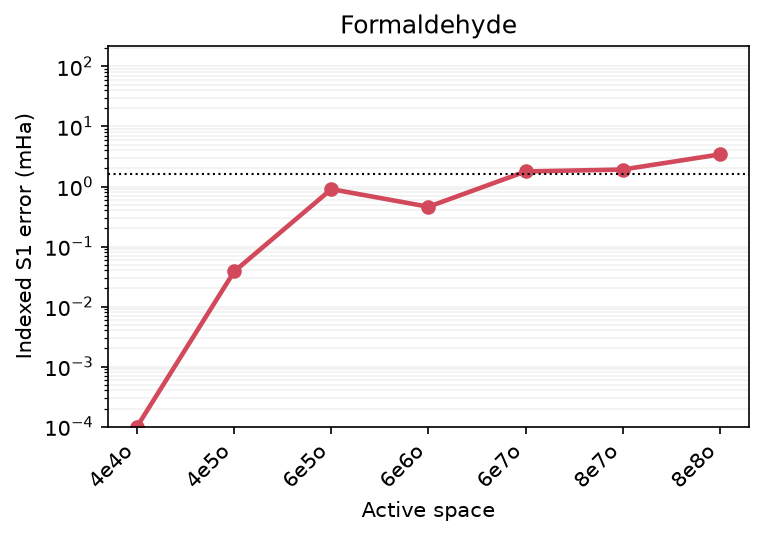
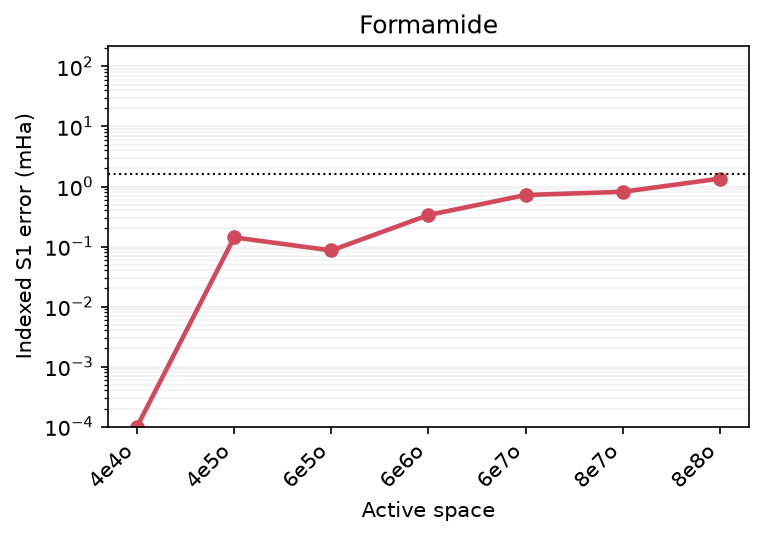
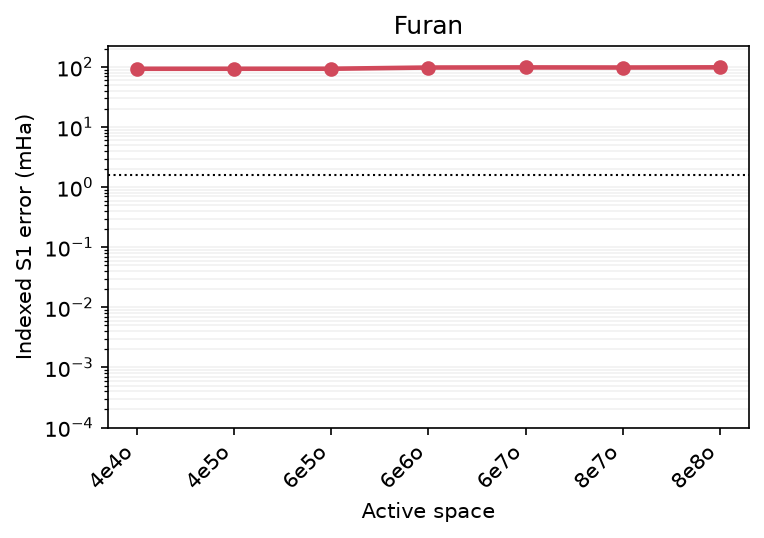
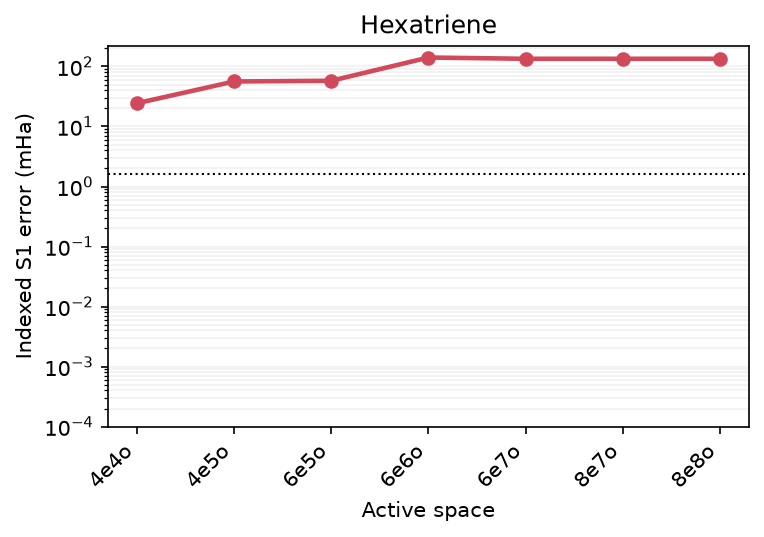
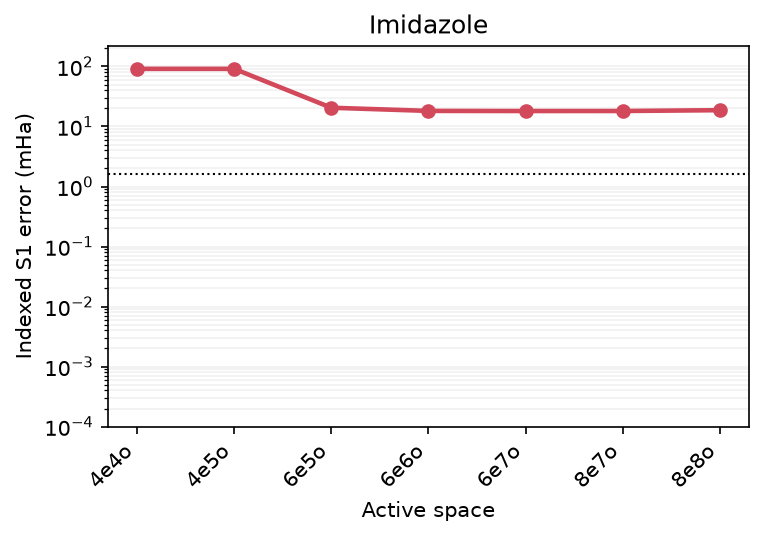
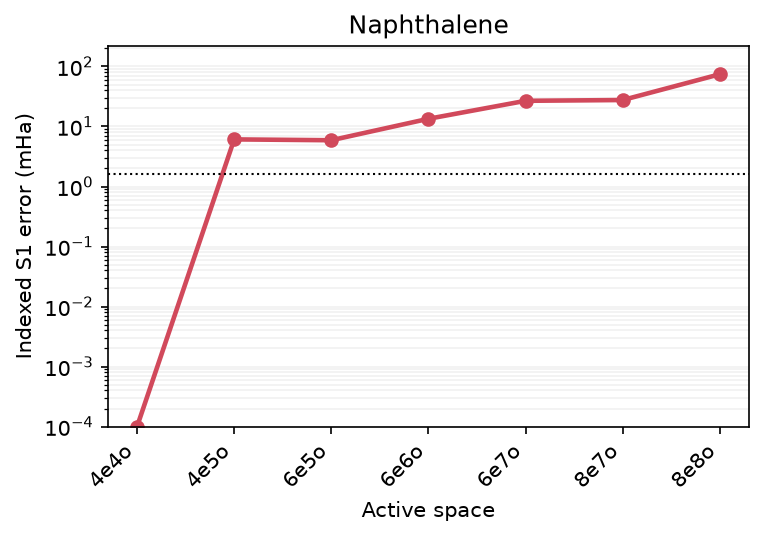
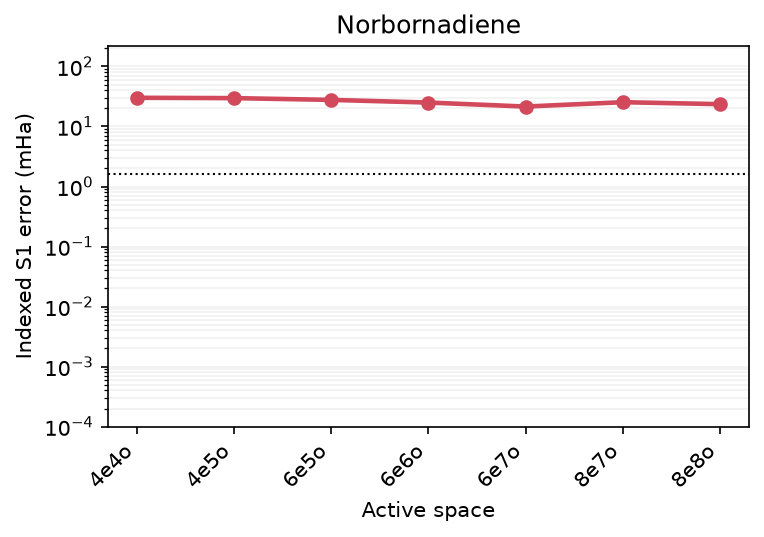
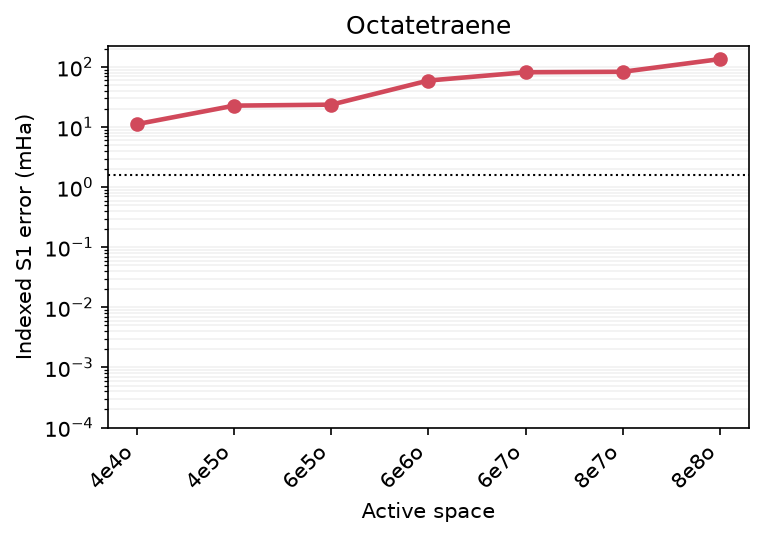
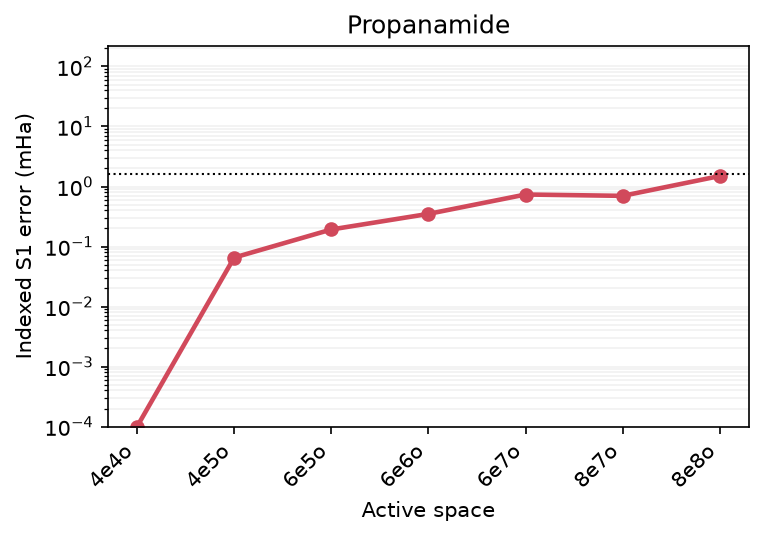
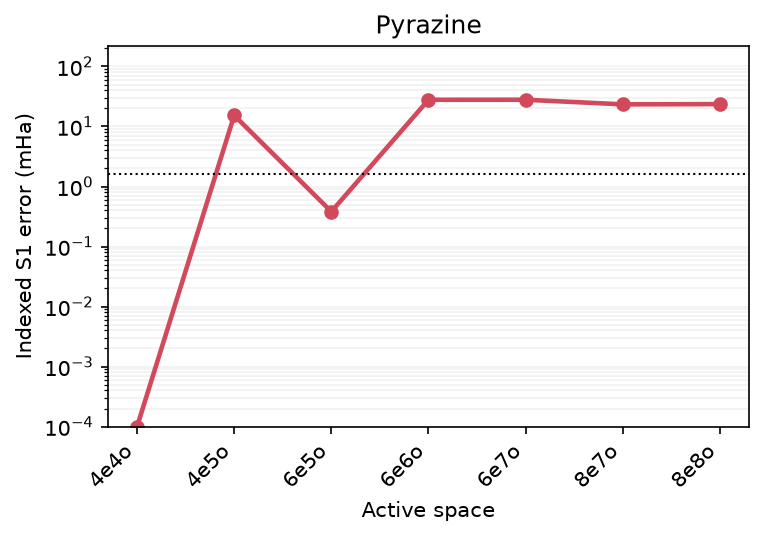
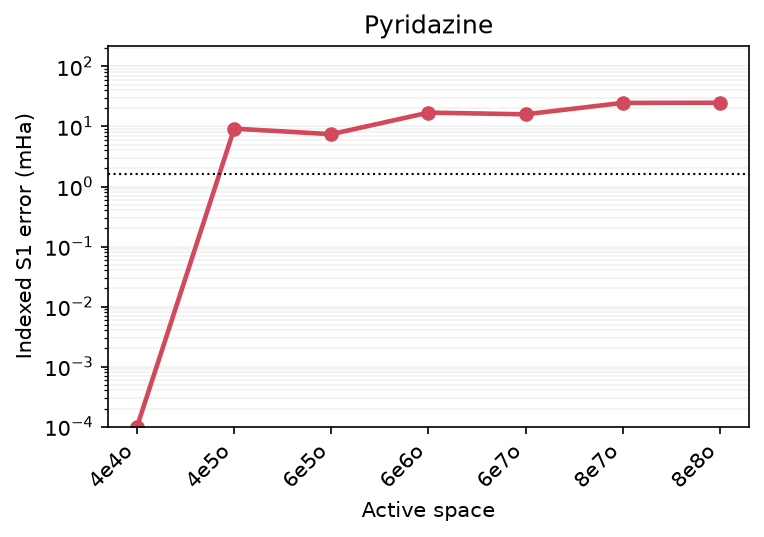
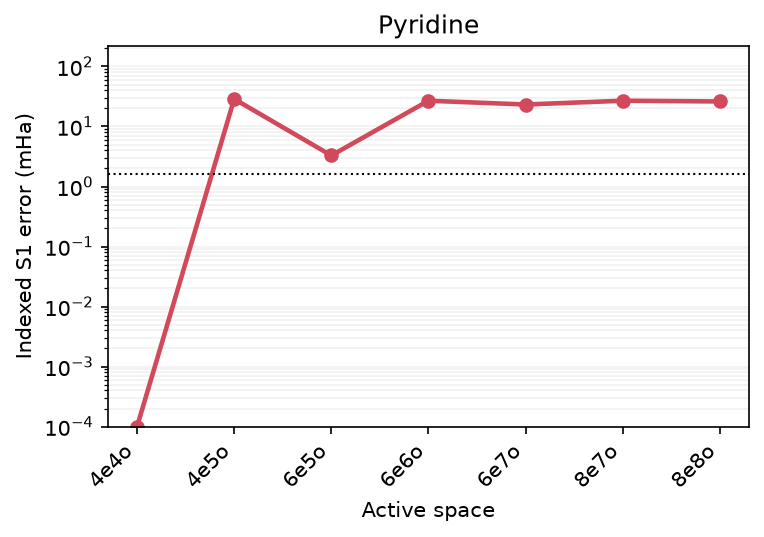
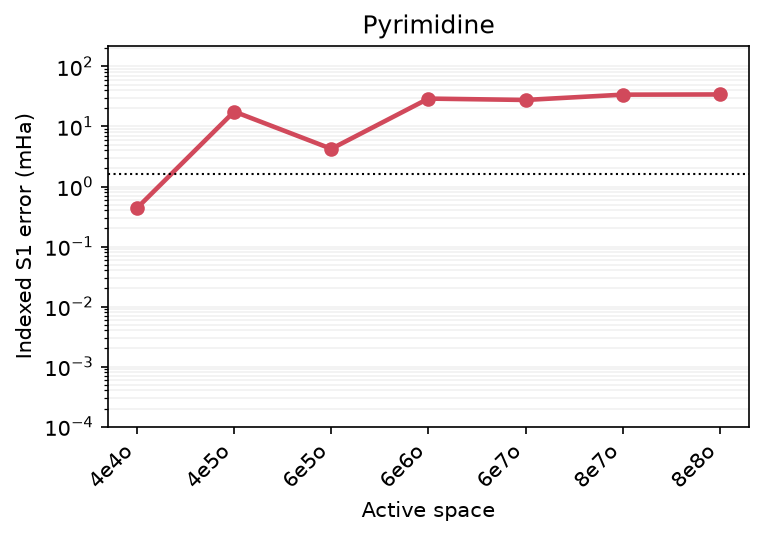
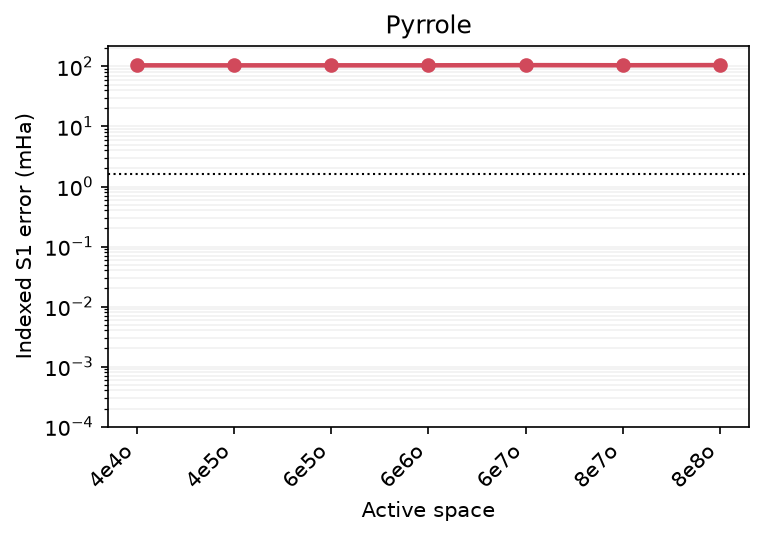
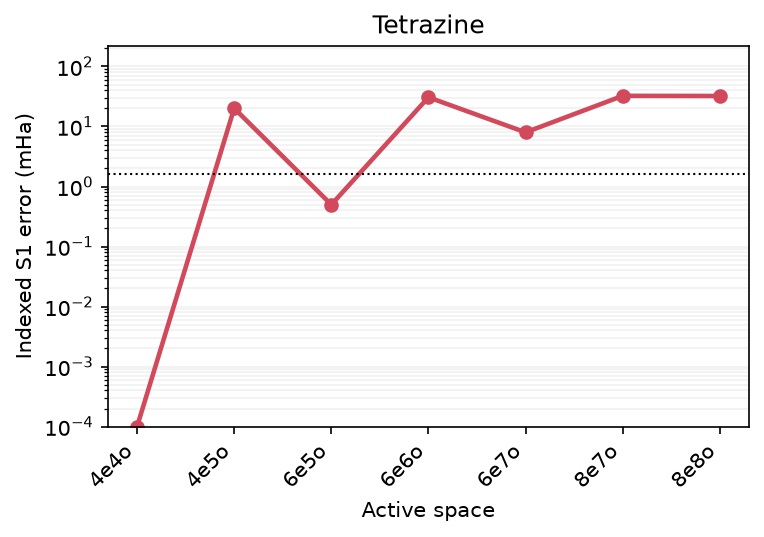
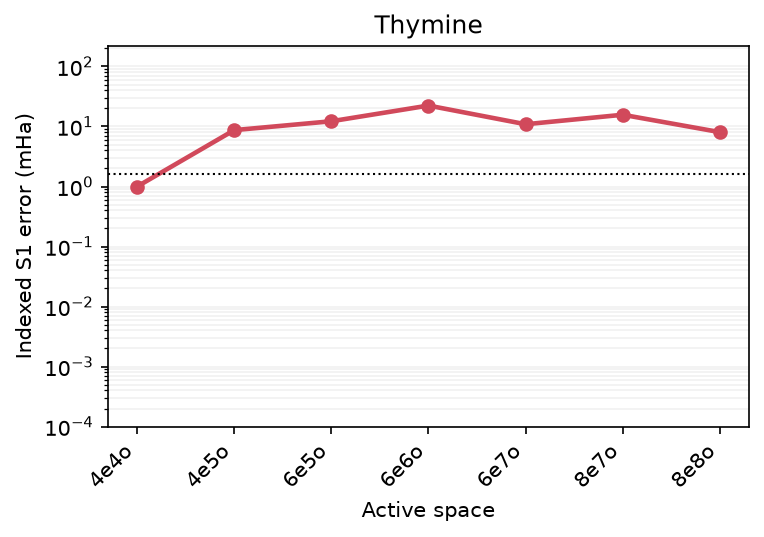
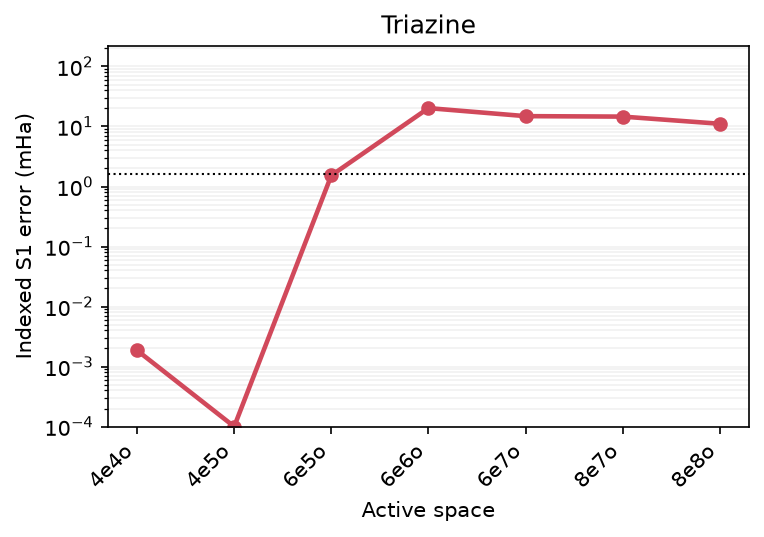
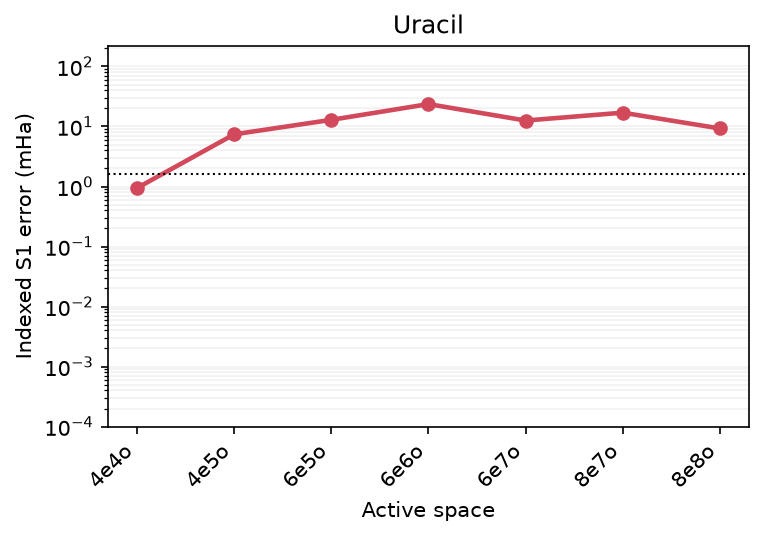

In [12]:
WINDOW_ACTIVE_SPACES = ["4e4o", "4e5o", "6e5o", "6e6o", "6e7o", "8e7o", "8e8o"]

df_s1_active_space_errors = df_raw_data.loc[
    df_raw_data["active_space"].isin(WINDOW_ACTIVE_SPACES),
    ["molecule", "active_space", "s1"],
].rename(columns={"s1": "error_mHa"})
df_s1_active_space_errors["active_space"] = pd.Categorical(
    df_s1_active_space_errors["active_space"], WINDOW_ACTIVE_SPACES, ordered=True
)
df_s1_active_space_errors = df_s1_active_space_errors.sort_values(["molecule", "active_space"])

print(f"Prepared {len(df_s1_active_space_errors):,} UCCSD S1 error records.")
import warnings

orbital_window_error_figures = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="More than 20 figures have been opened")
    for molecule in MOLECULE_NAMES:
        figure = plot_s1_active_space_error(df_s1_active_space_errors, molecule)
        save_figure(
            figure,
            "active_space_representability/orbital_window_errors",
            f"uccsd_s1_error_{molecule.lower().replace(' ', '_')}",
        )
        orbital_window_error_figures.append(figure)
show_scrollable_figs(orbital_window_error_figures)

Prepared 280 direct q1 overlap records.



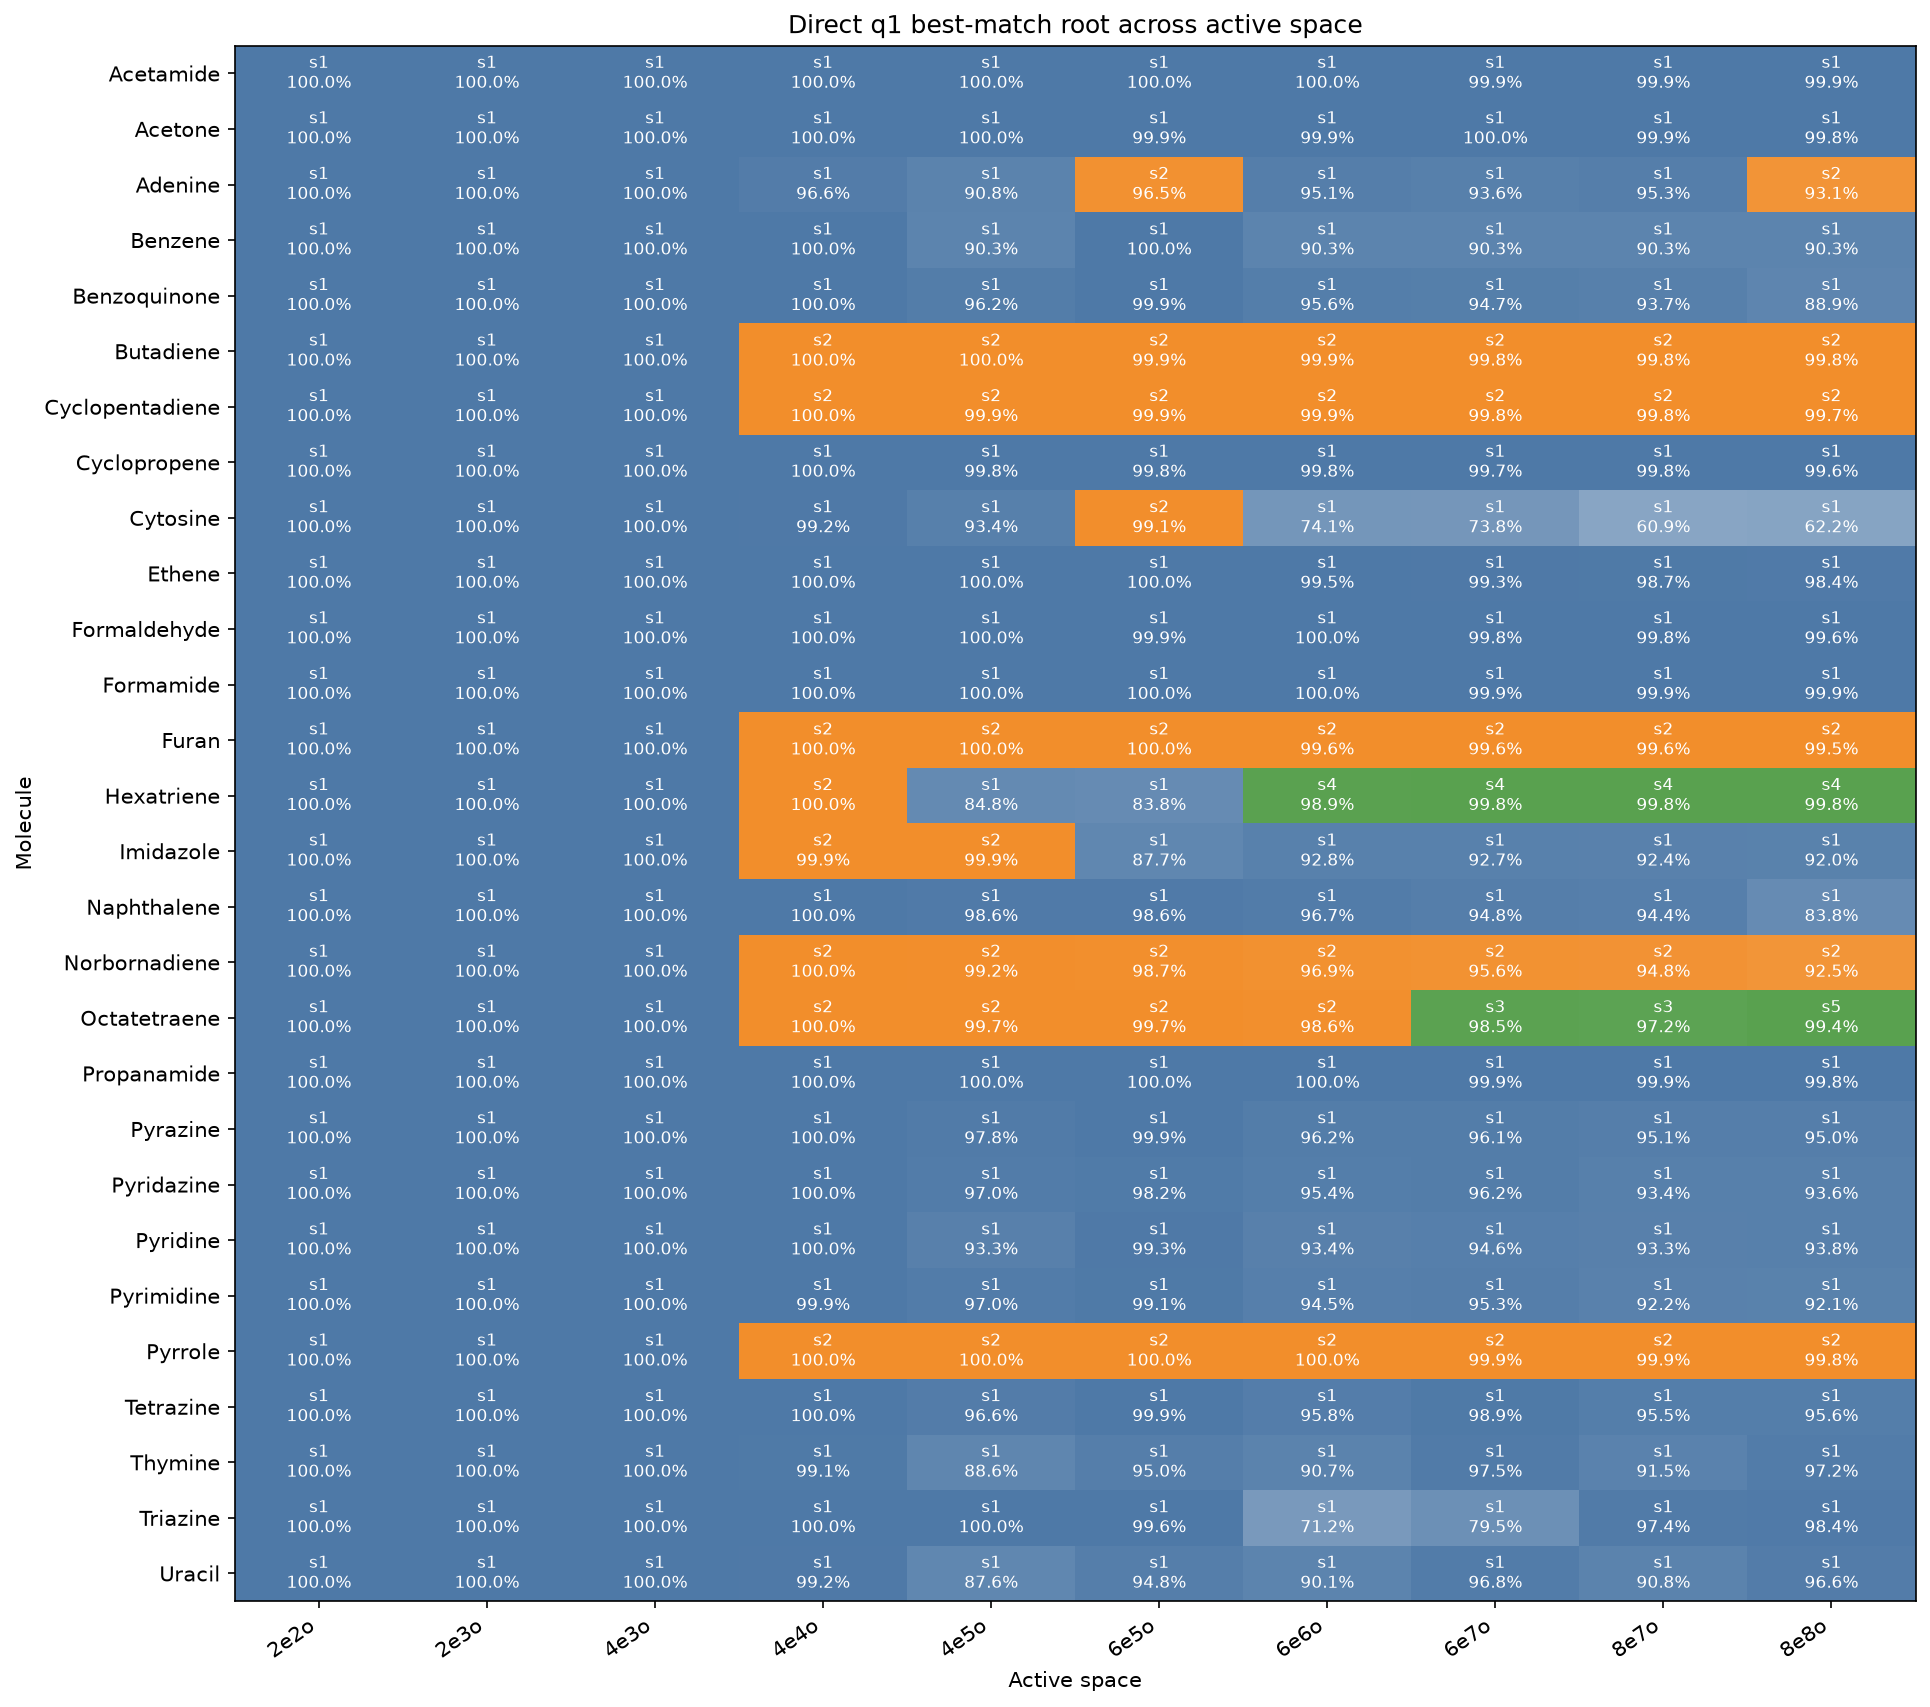

In [13]:
def get_q1_best_root_overlaps(df_UCCSD):
    df_singlet = df_UCCSD[df_UCCSD["expansion"] == "singlet"]
    overlap_rows = []

    for _, row in df_singlet.iterrows():
        _, qse_wavefunctions, _ = solve_energy_spin_th(
            row["H"], row["S"], row["S2"], threshold=1e-8
        )
        key = (row["molecule"], row["active_space"], row["ansatz"], row["expansion"])
        q1 = qse_state_matrices[key] @ qse_wavefunctions[:, 1]
        q1 /= np.linalg.norm(q1)
        root_overlaps = []

        for root_index, exact_root in row["pyscf_casci_pvec"].items():
            exact_root = np.asarray(exact_root, dtype=complex)
            exact_root /= np.linalg.norm(exact_root)
            overlap = 100 * min(abs(np.vdot(exact_root, q1)) ** 2, 1.0)
            root_overlaps.append((int(root_index), overlap))

        best_root, best_overlap = max(root_overlaps, key=lambda item: item[1])
        overlap_rows.append({
            "molecule": row["molecule"],
            "active_space": row["active_space"],
            "best_exact_root": f"s{best_root}",
            "overlap_percent": best_overlap,
        })

    active_space_order = sorted(df_singlet["active_space"].unique(), key=parse_active_space)
    df_overlap = pd.DataFrame(overlap_rows)
    df_overlap["molecule"] = pd.Categorical(df_overlap["molecule"], MOLECULE_NAMES, ordered=True)
    df_overlap["active_space"] = pd.Categorical(
        df_overlap["active_space"], active_space_order, ordered=True
    )
    return df_overlap.sort_values(["molecule", "active_space"]).reset_index(drop=True)

df_q1_best_root_overlaps = get_q1_best_root_overlaps(df_UCCSD)
print(f"Prepared {len(df_q1_best_root_overlaps):,} direct q1 overlap records.")
q1_best_root_figure = plot_q1_best_root_transition_map(df_q1_best_root_overlaps)
save_figure(
    q1_best_root_figure,
    "active_space_representability",
    "uccsd_q1_best_root_transition_map",
)
show_scrollable_figs([q1_best_root_figure])


## Ansatz Comparison 6e6o

In [14]:
# Select the complete six-ansatz benchmark at 6e6o.
df_6e6o = df_sv[df_sv["active_space"] == "6e6o"].copy()

ANSATZ_FUNCTIONS = {
    "1UpCCGSDSinglet": partial(Ansatz_kUpCCGSDSinglet, k=1),
    "2UpCCGSDSinglet": partial(Ansatz_kUpCCGSDSinglet, k=2),
    "3UpCCGSDSinglet": partial(Ansatz_kUpCCGSDSinglet, k=3),
    "UCCSDSinglet": Ansatz_UCCSDSinglet,
    "UCCSD": Ansatz_UCCSD,
    "UCCGSD": Ansatz_UCCGSD,
}
ANSATZ_ORDER = list(ANSATZ_FUNCTIONS)


def get_ansatz_complexity(active_space, ansatz_name):
    # Return the parameter count and circuit depth for one active space and ansatz.
    num_electrons, num_orbitals = parse_active_space(active_space)
    molecule = SimpleNamespace(
        nelec=num_electrons,
        nso=2 * num_orbitals,
        n_active_e=None,
        n_active_orbs=None,
    )
    ansatz = ANSATZ_FUNCTIONS[ansatz_name](molecule, use_mp2_guess=False)
    return len(ansatz.param_names), ansatz.circuit.depth


df_ansatz_details_6e6o = pd.DataFrame([
    {
        "ansatz": ansatz_name,
        "num_parameters": get_ansatz_complexity("6e6o", ansatz_name)[0],
        "circuit_depth": get_ansatz_complexity("6e6o", ansatz_name)[1],
    }
    for ansatz_name in ANSATZ_ORDER
])

print(f"Selected {len(df_6e6o):,} 6e6o statevector rows.")
display(df_ansatz_details_6e6o)

Selected 336 6e6o statevector rows.


,ansatz,num_parameters,circuit_depth
0,1UpCCGSDSinglet,30,1306
1,2UpCCGSDSinglet,60,2470
2,3UpCCGSDSinglet,90,3634
3,UCCSDSinglet,54,14692
4,UCCSD,117,12249
5,UCCGSD,315,37622


In [15]:
# Calculate median low-lying QSE errors across the 28-molecule 6e6o benchmark.
df_singlet_medians = (
    df_6e6o[df_6e6o["expansion"] == "singlet"]
    .groupby("ansatz")[["s0_error", "s1_error"]]
    .median()
)
df_triplet_medians = (
    df_6e6o[df_6e6o["expansion"] == "triplet"]
    .groupby("ansatz")[["t1_error", "t2_error"]]
    .median()
)

df_median_errors_6e6o = (
    df_singlet_medians.join(df_triplet_medians)
    .rename(columns={
        "s0_error": "s0",
        "s1_error": "s1",
        "t1_error": "t1",
        "t2_error": "t2",
    })
    .reindex(ANSATZ_ORDER)
)
df_median_errors_6e6o.index.name = None

df_ansatz_comparison_6e6o = (
    df_ansatz_details_6e6o.set_index("ansatz")
    .join(df_median_errors_6e6o)
    .reset_index()
)

display(df_ansatz_comparison_6e6o)


,ansatz,num_parameters,circuit_depth,s0,s1,t1,t2
0,1UpCCGSDSinglet,30,1306,17.387874,35.931121,6.019923,18.898685
1,2UpCCGSDSinglet,60,2470,6.709098,31.392959,2.103562,5.587717
2,3UpCCGSDSinglet,90,3634,4.139297,28.234018,2.654452,4.097164
3,UCCSDSinglet,54,14692,0.195638,23.691796,2.398113,3.158419
4,UCCSD,117,12249,0.143323,23.690645,2.629878,2.779057
5,UCCGSD,315,37622,0.078726,22.248835,1.572466,2.111090


In [17]:
# Analysis on VQE composition at 6e6o.
def get_vqe_exact_state_overlaps(df_6e6o):
    """Return normalized squared CASCI overlaps (0-1) for each cached VQE state."""
    active_space = "6e6o"
    # Restrict the full circuit vec to pvec with determinant indices
    determinant_indices = [i for i in range(4096) if i.bit_count() == 6]
    exact_rows = df_6e6o.set_index(["molecule", "ansatz", "expansion"])
    state_roots = {
        "singlet": {"s0": ("0",), "s1": ("1",)},
        "triplet": {"t1": ("0_0", "0_p1", "0_m1"), "t2": ("1_0", "1_p1", "1_m1")},
    }
    records = []
    for molecule_name in MOLECULE_NAMES:
        molecule = load_qibo_mol(molecule_name, active_space)
        for ansatz_name in ANSATZ_ORDER:
            circuit = get_vqe_circuit(molecule, molecule_name, active_space, ansatz_name)
            full_state = np.asarray(circuit().state(), dtype=complex)
            vqe_pvec = full_state[determinant_indices]
            vqe_pvec = vqe_pvec / np.linalg.norm(vqe_pvec)

            record = {"molecule": molecule_name, "ansatz": ansatz_name}
            for expansion, states in state_roots.items():
                exact_pvecs = exact_rows.loc[(molecule_name, ansatz_name, expansion), "pyscf_casci_pvec"]
                for state, root_keys in states.items():
                    sector_overlaps = []
                    for root in root_keys:
                        exact_pvec = np.asarray(exact_pvecs[root], dtype=complex)
                        exact_pvec = exact_pvec / np.linalg.norm(exact_pvec)
                        sector_overlaps.append(abs(np.vdot(exact_pvec, vqe_pvec)) ** 2)
                    record[state] = float(np.mean(sector_overlaps))
            records.append(record)
    return pd.DataFrame(records)


df_vqe_exact_state_overlaps = get_vqe_exact_state_overlaps(df_6e6o)
vqe_overlap_states = ["s0", "s1", "t1", "t2"]
df_mean_vqe_exact_state_overlaps = (
    df_vqe_exact_state_overlaps.groupby("ansatz")[vqe_overlap_states].mean().reindex(ANSATZ_ORDER)
)
df_mean_vqe_exact_state_overlaps.loc["Overall"] = df_vqe_exact_state_overlaps[vqe_overlap_states].mean()
df_mean_vqe_exact_state_overlaps_percent = df_mean_vqe_exact_state_overlaps.mul(100).round(2)
df_mean_vqe_exact_state_overlaps_percent.index.name = "Ansatz"
display(df_mean_vqe_exact_state_overlaps.style.format("{:.6g}").set_caption(
    "Mean squared VQE overlap with exact CASCI states at 6e6o"
))

df_max_vqe_exact_state_overlaps = (
    df_vqe_exact_state_overlaps.groupby("ansatz")[vqe_overlap_states]
    .max().reindex(ANSATZ_ORDER)
)
df_max_vqe_exact_state_overlaps.loc["Overall"] = (
    df_vqe_exact_state_overlaps[vqe_overlap_states].max()
)
df_max_vqe_exact_state_overlaps_percent = df_max_vqe_exact_state_overlaps.mul(100).round(2)
df_max_vqe_exact_state_overlaps_percent.index.name = "Ansatz"
display(df_max_vqe_exact_state_overlaps.style.format("{:.6g}").set_caption(
    "Maximum squared VQE overlap with exact CASCI states at 6e6o"
))


,s0,s1,t1,t2
Ansatz,,,,
1UpCCGSDSinglet,0.967877,0.000836209,2.97185e-30,4.57258e-31
2UpCCGSDSinglet,0.981762,0.00132952,2.41562e-30,3.66651e-31
3UpCCGSDSinglet,0.9848,0.000454653,2.49061e-30,3.19262e-31
UCCSDSinglet,0.998843,3.72881e-05,5.14625e-08,2.03123e-07
UCCSD,0.998989,1.55541e-05,4.44726e-07,2.11835e-07
UCCGSD,0.99976,3.94e-06,8.65705e-07,1.5101e-06
Overall,0.988672,0.000446193,2.26982e-07,3.20843e-07


,s0,s1,t1,t2
Ansatz,,,,
1UpCCGSDSinglet,0.999554,0.0101208,3.66247e-29,3.27171e-30
2UpCCGSDSinglet,0.999604,0.0178822,3.23571e-29,2.85814e-30
3UpCCGSDSinglet,0.999718,0.00404168,3.39487e-29,2.342e-30
UCCSDSinglet,0.999997,0.000540591,1.40328e-06,4.96018e-06
UCCSD,0.999997,0.000295096,9.42883e-06,4.79937e-06
UCCGSD,0.999997,8.98465e-05,1.57344e-05,3.20842e-05
Overall,0.999997,0.0178822,1.57344e-05,3.20842e-05


## Spin Contamination

In [18]:
def get_bad_spin_root_data(active_space, df_sv, spin_threshold):
    """
    For one active space from df_sv, return the 
    1) contamination values above threshold by one-based raw eigenvector index
    2) mean spin contamination for the grouped low lying states
    
    """
    df_active = df_sv[df_sv["active_space"] == active_space]
    bad_spin_roots = {}
    mean_spin_contamination = {}

    for ansatz in ANSATZ_FUNCTIONS:
        df_active_ansatz = df_active[df_active["ansatz"] == ansatz]
        bad_spin_roots[ansatz] = {}
        mean_spin_contamination[ansatz] = {}

        for expansion in ("singlet", "triplet"):
            df_expansion = df_active_ansatz[df_active_ansatz["expansion"] == expansion]
            # Reference that one column containing all the spin contamination values 
            # tolist creates an outerlist, DataFrame pads missing values with nan
            spin_values = pd.DataFrame(
                df_expansion["full_spin_contamination"].tolist()
            )

            # Count contamination per raw eigenvector, without triplet grouping.
            raw_spin_values = pd.DataFrame(df_expansion["full_spin_values"].tolist())
            target_spin = 0.0 if expansion == "singlet" else 2.0
            raw_spin_contamination = (raw_spin_values - target_spin).abs()

            root_data = {
                root + 1: values[values > spin_threshold].to_numpy()
                for root, values in raw_spin_contamination.items()
            }
            # Separate by ansatz and singlet/triplet
            bad_spin_roots[ansatz][expansion] = root_data

            # For low lying states, update the mean error for all roots
            low_lying_states = ("s0", "s1") if expansion == "singlet" else ("t1", "t2")
            mean_spin_contamination[ansatz].update({
                state: float(
                    spin_values.iloc[:, root].mean()
                    ) 
                    # For t2 missing states (2e2o)
                    if root < spin_values.shape[1] else np.nan
                    for root, state in enumerate(low_lying_states)
            })
    # Returns both as a dictionary
    return bad_spin_roots, mean_spin_contamination


s0            s1            t1  \
active_space                                                             
6e6o         1UpCCGSDSinglet  1.706331e-12  4.356294e-11  9.806998e-11   
             2UpCCGSDSinglet  8.318797e-12  4.925706e-11  6.780735e-12   
             3UpCCGSDSinglet  4.164542e-12  2.343189e-10  1.417250e-11   
             UCCSDSinglet     4.508813e-04  3.225232e-04  1.761380e-04   
             UCCSD            2.307794e-04  1.450824e-04  4.297835e-04   
             UCCGSD           1.933899e-04  3.907472e-03  4.369604e-04   

                                        t2  
active_space                                
6e6o         1UpCCGSDSinglet  1.023389e-09  
             2UpCCGSDSinglet  1.931179e-11  
             3UpCCGSDSinglet  2.272567e-10  
             UCCSDSinglet     2.197697e-04  
             UCCSD            5.390986e-04  
             UCCGSD           6.285361e-04


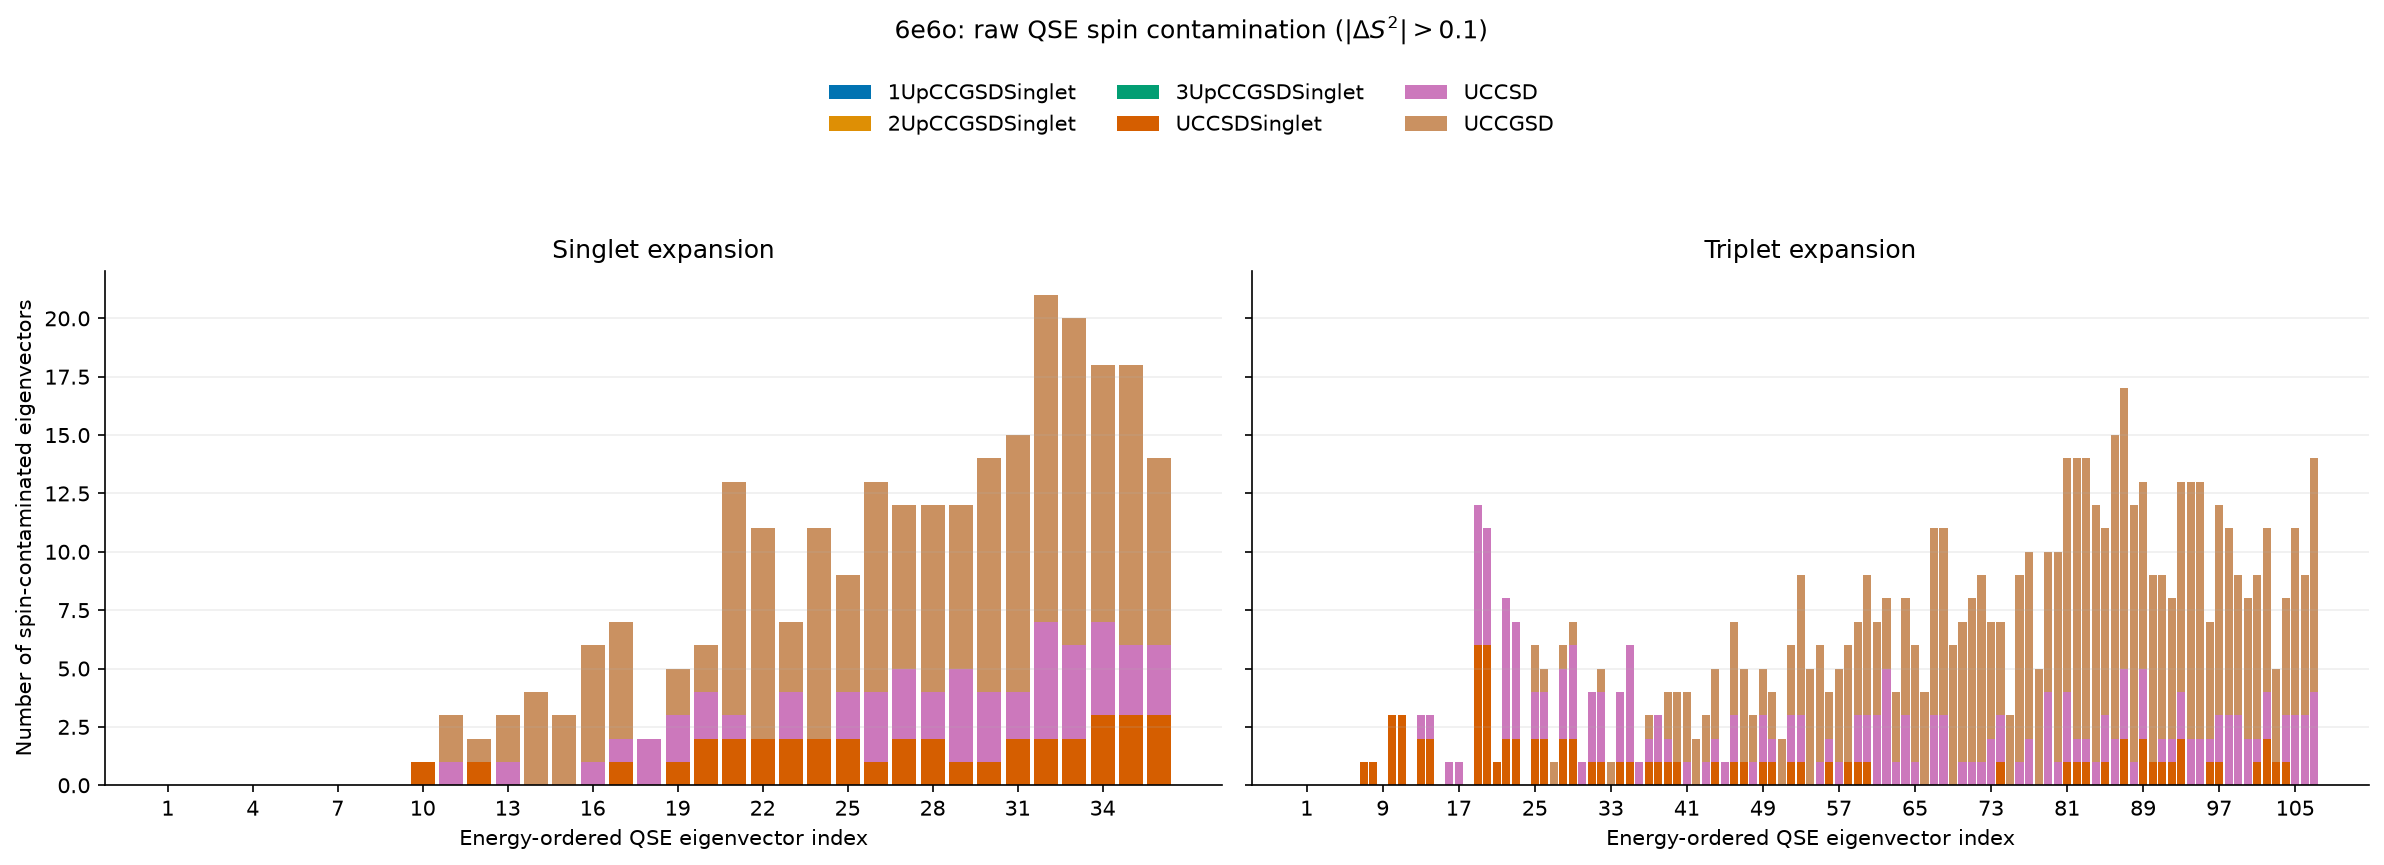

In [19]:
# Build, save, and display the six-ansatz 6e6o spin-contamination analysis.
active_space = "6e6o"
BAD_SPIN_THRESHOLD = 0.1

bad_spin_roots, mean_spin_contamination = get_bad_spin_root_data(
    active_space, df_6e6o, BAD_SPIN_THRESHOLD
)
df_mean = (
    pd.DataFrame(mean_spin_contamination).T
    .reindex(ANSATZ_ORDER)[["s0", "s1", "t1", "t2"]]
)

bad_spin_roots_by_space = {active_space: bad_spin_roots}
mean_spin_contamination_by_space = {active_space: mean_spin_contamination}
mean_spin_tables = {active_space: df_mean}

df_mean_spin_contamination = pd.concat(mean_spin_tables, names=["active_space"])

figure = plot_bad_spin_roots(bad_spin_roots, active_space, BAD_SPIN_THRESHOLD)
save_figure(figure, "active_space_representability/spin_contamination", f"bad_spin_roots_{active_space}")

display(df_mean_spin_contamination)
show_scrollable_figs([figure])

,ansatz,expansion,severe_eigenvectors,affected_molecules,total_molecules,earliest_index,median_first_index
0,1UpCCGSDSinglet,singlet,0,0,28,NaN,NaN
1,1UpCCGSDSinglet,triplet,0,0,28,NaN,NaN
2,2UpCCGSDSinglet,singlet,0,0,28,NaN,NaN
3,2UpCCGSDSinglet,triplet,0,0,28,NaN,NaN
4,3UpCCGSDSinglet,singlet,0,0,28,NaN,NaN
5,3UpCCGSDSinglet,triplet,0,0,28,NaN,NaN
6,UCCGSD,singlet,5,4,28,14.0,19.0
7,UCCGSD,triplet,39,16,28,46.0,75.5
8,UCCSD,singlet,2,2,28,11.0,22.0
9,UCCSD,triplet,34,16,28,13.0,22.0



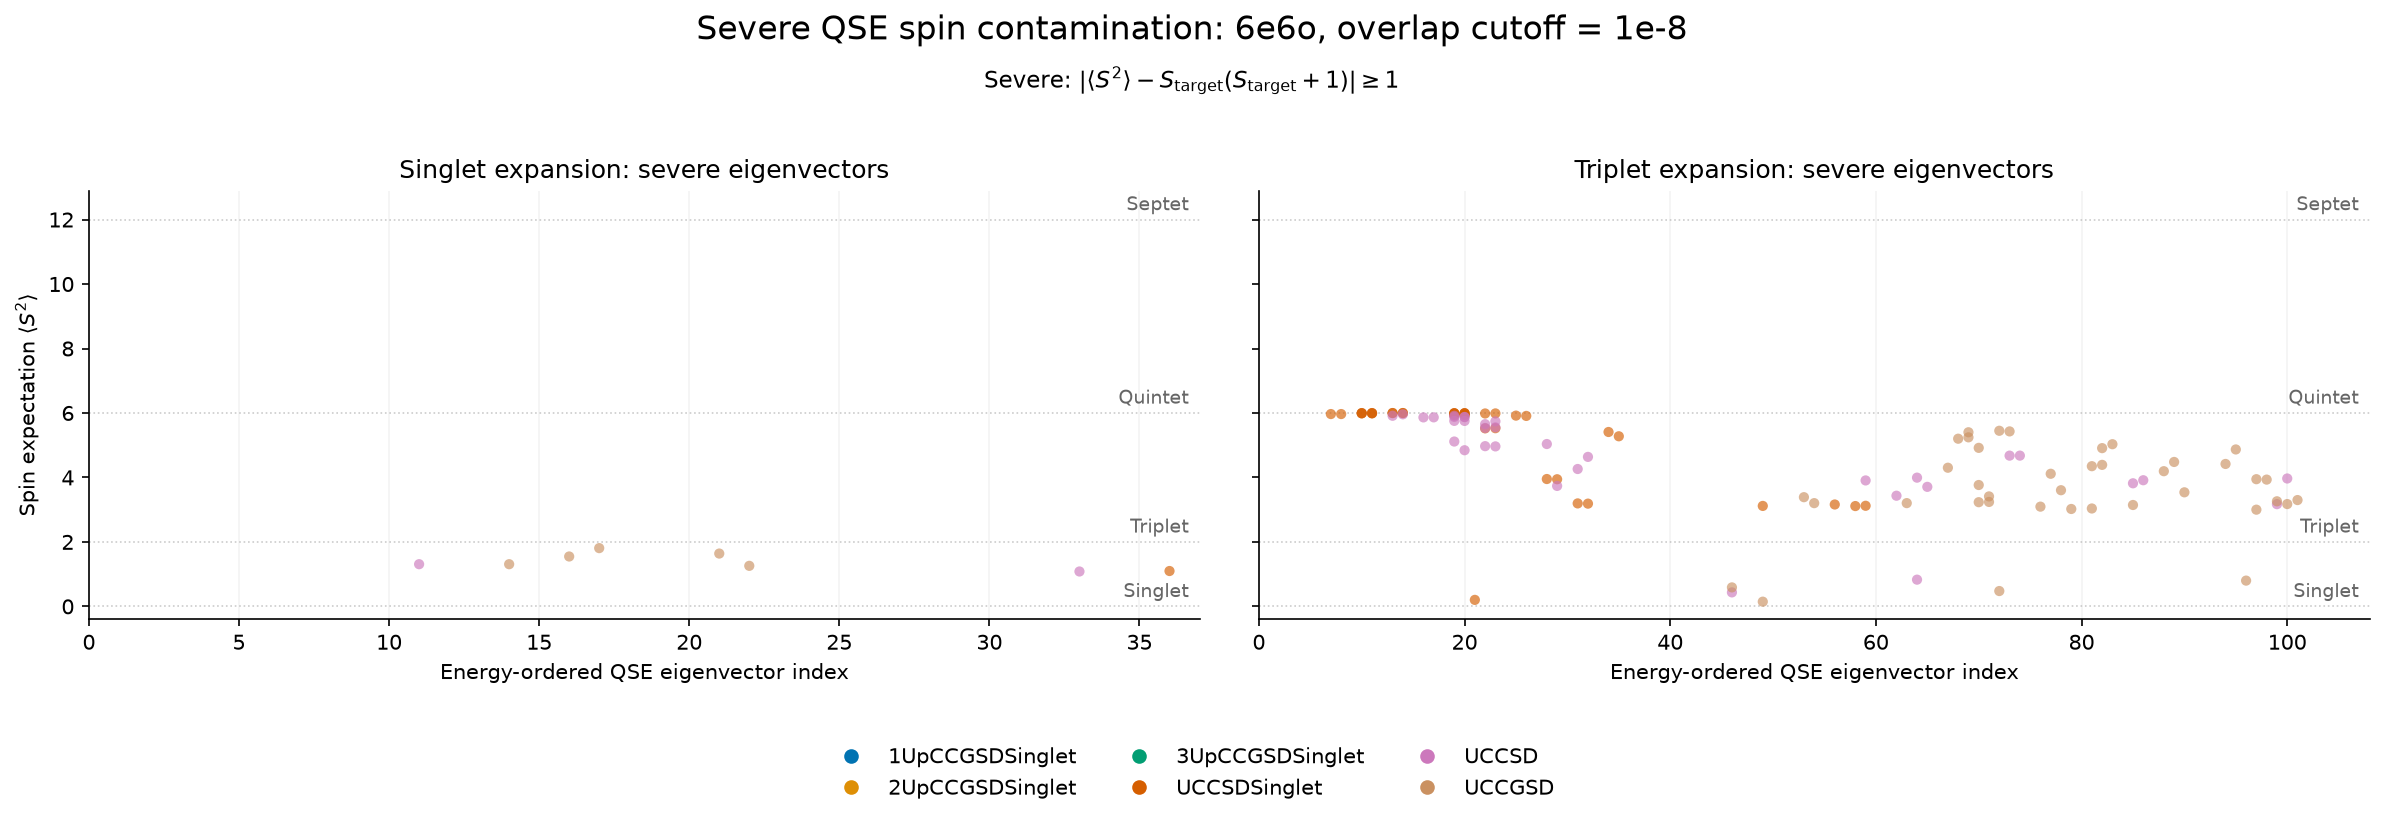

In [20]:
# Severe raw-root spin diagnostics; full_spin_values was solved at threshold=1e-8.
def get_severe_spin_root_data(df_6e6o, spin_threshold=1.0):
    """Return severe eigenvectors, first appearances, and an ansatz summary.

    Keep absent first appearances as NaN, without grouping triplet eigenvectors.
    """
    severe_records, first_records = [], []
    for _, row in df_6e6o.iterrows():
        identity = {name: row[name] for name in ("molecule", "ansatz", "expansion")}
        spin_values = np.asarray(row["full_spin_values"], dtype=float)
        target_spin = 0.0 if row["expansion"] == "singlet" else 2.0
        contamination = np.abs(spin_values - target_spin)
        severe_indices = np.flatnonzero(np.isfinite(spin_values) & (contamination >= spin_threshold))
        records = [
            {**identity, "raw_index": int(index + 1), "spin_squared": spin_values[index],
             "spin_contamination": contamination[index]}
            for index in severe_indices
        ]
        severe_records.extend(records)
        first = records[0] if records else {
            **identity, "raw_index": np.nan, "spin_squared": np.nan, "spin_contamination": np.nan
        }
        first_records.append({
            **first, "num_retained": len(spin_values), "num_severe": len(records)
        })

    columns = ["molecule", "ansatz", "expansion", "raw_index", "spin_squared", "spin_contamination"]
    severe_roots = pd.DataFrame(severe_records, columns=columns)
    first_roots = pd.DataFrame(first_records)
    summary = first_roots.groupby(["ansatz", "expansion"], sort=False).agg(
        severe_eigenvectors=("num_severe", "sum"),
        affected_molecules=("raw_index", "count"),
        total_molecules=("molecule", "size"),
        earliest_index=("raw_index", "min"),
        median_first_index=("raw_index", "median"),
    ).reset_index()
    return severe_roots, first_roots, summary


df_severe_spin_roots, df_first_severe_spin_roots, df_severe_spin_summary = (
    get_severe_spin_root_data(df_6e6o)
)
display(df_severe_spin_summary)
figure = plot_severe_spin_root_diagnostic(
    df_severe_spin_roots, df_first_severe_spin_roots, ANSATZ_ORDER
)
save_figure(
    figure, "active_space_representability/spin_contamination",
    "severe_spin_roots_6e6o",
)
show_scrollable_figs([figure])


In [ ]:
"""
Compare UCCSD and UCCSDSinglet effect of trotter steps
Re run VQE from the canonical qibo molecule with different trotter steps
"""

active_space = "4e4o"
trotter_ladder = (1, 2, 4, 8, 16, 32)
trotter_ansatzes = {
    "UCCSDSinglet": Ansatz_UCCSDSinglet,
    "UCCSD": Ansatz_UCCSD,
}

trotter_spin_rows = []

for molecule_name in MOLECULE_NAMES:
    molecule = load_qibo_mol(molecule_name, active_space)

    for ansatz_name, ansatz_function in trotter_ansatzes.items():
        for trotter_steps in trotter_ladder:
            ansatz = ansatz_function(molecule, trotter_steps=trotter_steps)
            vqe_energy, _, final_circuit = ansatz.run_vqe(StateVectorProtocol(), method="L-BFGS-B", fast=True)
            vqe_state = final_circuit().state()

            trotter_spin_rows.append({
                "molecule": molecule_name,
                "active_space": active_space,
                "ansatz": ansatz_name,
                "trotter_steps": trotter_steps,
                "num_parameters": len(ansatz.param_names),
                "circuit_depth": final_circuit.depth,
                "vqe_energy_Ha": float(vqe_energy),
                "spin_contamination": get_vqe_spin_contamination(vqe_state, active_space),
            })

df_trotter_spin_results = pd.DataFrame(trotter_spin_rows)
df_trotter_spin_mean = (
    df_trotter_spin_results.groupby(["ansatz", "trotter_steps"], sort=False)
    .agg(
        num_molecules=("molecule", "nunique"),
        num_parameters=("num_parameters", "first"),
        circuit_depth=("circuit_depth", "first"),
        mean_spin_contamination=("spin_contamination", "mean"),
    )
    .reset_index()
)

df_trotter_spin_results.to_csv(PROCESSED_DATAFRAMES_DIR / "uccsd_trotter_spin_results_4e4o.csv", index=False)
display(df_trotter_spin_mean)


[Qibo 0.3.2|INFO|2026-09-05 21:16:56]: Using numpy backend on /CPU:0


,ansatz,trotter_steps,num_molecules,num_parameters,circuit_depth,mean_spin_contamination
0,UCCSDSinglet,1,28,14,2181,2.943113e-06
1,UCCSDSinglet,2,28,14,4370,6.894982e-07
2,UCCSDSinglet,4,28,14,8748,1.690743e-07
3,UCCSDSinglet,8,28,14,17504,4.205176e-08
4,UCCSDSinglet,16,28,14,35016,1.049051e-08
5,UCCSDSinglet,32,28,14,70040,2.620550e-09
6,UCCSD,1,28,26,1951,1.207535e-08
7,UCCSD,2,28,26,3939,1.370162e-08
8,UCCSD,4,28,26,7915,2.079582e-08
9,UCCSD,8,28,26,15867,1.926998e-08
